In [96]:
import os
import zipfile
import json
import re
import pandas as pd
import numpy as np

# Chemins locaux PyCharm
base = "../"
ZIP_PATH = base + "data/data.zip"
OUTPUT_DIR = base + "outputs_anssi"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ ZIP_PATH   : {ZIP_PATH}")
print(f"✅ OUTPUT_DIR : {OUTPUT_DIR}")
print(f"✅ ZIP existe : {os.path.exists(ZIP_PATH)}")

✅ ZIP_PATH   : ../data/data.zip
✅ OUTPUT_DIR : ../outputs_anssi
✅ ZIP existe : True


To help locate the `data.zip` file, let's list the contents of your Google Drive's 'SharedWithMe' directory. This might help you find the exact path.

After running the cell above, look for `data.zip` in the output. Once you find its full path, copy it and update the `BASE_DIR` variable in the first code cell (`zkSch9kvzaOj`) to reflect the correct parent directory of `data.zip`.

#Début projet mise en place de la data

In [97]:
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    fichiers_zip = z.namelist()

print("Nombre total de fichiers dans le zip :", len(fichiers_zip))
print(fichiers_zip[:20])

Nombre total de fichiers dans le zip : 78666
['data/', 'data/alertes/', 'data/alertes/CERTFR-2021-ALE-001', 'data/alertes/CERTFR-2021-ALE-002', 'data/alertes/CERTFR-2021-ALE-003', 'data/alertes/CERTFR-2021-ALE-004', 'data/alertes/CERTFR-2021-ALE-005', 'data/alertes/CERTFR-2021-ALE-006', 'data/alertes/CERTFR-2021-ALE-007', 'data/alertes/CERTFR-2021-ALE-008', 'data/alertes/CERTFR-2021-ALE-009', 'data/alertes/CERTFR-2021-ALE-010', 'data/alertes/CERTFR-2021-ALE-011', 'data/alertes/CERTFR-2021-ALE-012', 'data/alertes/CERTFR-2021-ALE-013', 'data/alertes/CERTFR-2021-ALE-014', 'data/alertes/CERTFR-2021-ALE-015', 'data/alertes/CERTFR-2021-ALE-016', 'data/alertes/CERTFR-2021-ALE-017', 'data/alertes/CERTFR-2021-ALE-018']


In [98]:
alertes_files = [f for f in fichiers_zip if "/alertes/" in f and not f.endswith("/")]
avis_files = [f for f in fichiers_zip if "/Avis/" in f and not f.endswith("/")]
mitre_files = [f for f in fichiers_zip if "/mitre/" in f and not f.endswith("/")]
first_files = [f for f in fichiers_zip if "/first/" in f and not f.endswith("/")]

print("Alertes :", len(alertes_files))
print("Avis :", len(avis_files))
print("MITRE :", len(mitre_files))
print("FIRST :", len(first_files))


Alertes : 78
Avis : 4025
MITRE : 37279
FIRST : 37279


In [99]:
def lire_json_zip(zip_path, chemin_fichier):
    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(chemin_fichier) as f:
            return json.load(f)

In [100]:
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    fichiers = z.namelist()

print("Nombre total de fichiers dans le zip :", len(fichiers))
print(fichiers[:20])

Nombre total de fichiers dans le zip : 78666
['data/', 'data/alertes/', 'data/alertes/CERTFR-2021-ALE-001', 'data/alertes/CERTFR-2021-ALE-002', 'data/alertes/CERTFR-2021-ALE-003', 'data/alertes/CERTFR-2021-ALE-004', 'data/alertes/CERTFR-2021-ALE-005', 'data/alertes/CERTFR-2021-ALE-006', 'data/alertes/CERTFR-2021-ALE-007', 'data/alertes/CERTFR-2021-ALE-008', 'data/alertes/CERTFR-2021-ALE-009', 'data/alertes/CERTFR-2021-ALE-010', 'data/alertes/CERTFR-2021-ALE-011', 'data/alertes/CERTFR-2021-ALE-012', 'data/alertes/CERTFR-2021-ALE-013', 'data/alertes/CERTFR-2021-ALE-014', 'data/alertes/CERTFR-2021-ALE-015', 'data/alertes/CERTFR-2021-ALE-016', 'data/alertes/CERTFR-2021-ALE-017', 'data/alertes/CERTFR-2021-ALE-018']


In [101]:
exemple_alerte = alertes_files[0]
data_exemple = lire_json_zip(ZIP_PATH, exemple_alerte)

print("Fichier :", exemple_alerte)
print("Clés disponibles :", data_exemple.keys())

Fichier : data/alertes/CERTFR-2021-ALE-001
Clés disponibles : dict_keys(['$ref', 'affected_systems', 'affected_systems_content', 'closed_at', 'content', 'cves', 'links', 'reference', 'revisions', 'risks', 'summary', 'title', 'vendor_advisories'])


In [102]:
def extraire_infos_bulletin_v2(data, chemin_fichier, type_bulletin):
    id_anssi = chemin_fichier.split("/")[-1]
    titre = data.get("title", "")

    revisions = data.get("revisions", [])
    date_publication = min([r.get("revision_date","") for r in revisions]) if revisions else ""

    # Lien reconstruit proprement
    type_url = "alerte" if type_bulletin == "Alerte" else "avis"
    lien = f"https://www.cert.ssi.gouv.fr/{type_url}/{id_anssi}/"

    # CVE : combinaison regex + clé directe
    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    cves_regex = set(re.findall(cve_pattern, str(data)))
    cves_directes = {cve["name"] for cve in data.get("cves", []) if isinstance(cve, dict) and "name" in cve}
    liste_cve = sorted(cves_regex | cves_directes)

    return {
        "id_anssi": id_anssi,
        "type_bulletin": type_bulletin,
        "titre": titre,
        "date_publication": date_publication,
        "lien": lien,
        "nb_cve": len(liste_cve),
        "liste_cve": liste_cve
    }

In [103]:
bulletins = []

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for fichier in alertes_files:
        try:
            with z.open(fichier) as f:
                data = json.load(f)
            bulletins.append(extraire_infos_bulletin_v2(data, fichier, "Alerte"))
        except Exception as e:
            print("Erreur alerte :", fichier, e)

    for fichier in avis_files:
        try:
            with z.open(fichier) as f:
                data = json.load(f)
            bulletins.append(extraire_infos_bulletin_v2(data, fichier, "Avis"))
        except Exception as e:
            print("Erreur avis :", fichier, e)

df_bulletins = pd.DataFrame(bulletins)
print(f"✅ {len(df_bulletins)} bulletins chargés")

✅ 4103 bulletins chargés


In [104]:
# Exploser : 1 bulletin avec 5 CVE → 5 lignes
df_exploded = df_bulletins.explode("liste_cve").rename(columns={"liste_cve": "cve_id"})

# Supprimer les lignes sans CVE
df_exploded = df_exploded[df_exploded["cve_id"].notna() & (df_exploded["cve_id"] != "")].copy()
df_exploded = df_exploded.reset_index(drop=True)

print(f"Bulletins total     : {len(df_bulletins)}")
print(f"Dont avec CVE       : {df_bulletins[df_bulletins['nb_cve'] > 0].shape[0]}")
print(f"Lignes après explode: {len(df_exploded)}")
print(f"CVE uniques         : {df_exploded['cve_id'].nunique()}")
print(f"\nAperçu :")
df_exploded.head(10)

Bulletins total     : 4103
Dont avec CVE       : 3915
Lignes après explode: 125936
CVE uniques         : 37287

Aperçu :


,id_anssi,type_bulletin,titre,date_publication,lien,nb_cve,cve_id
0,CERTFR-2021-ALE-001,Alerte,|MàJ] Vulnérabilité dans SonicWall SMA100,2021-02-02T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,2,CVE-2014-6271
1,CERTFR-2021-ALE-001,Alerte,|MàJ] Vulnérabilité dans SonicWall SMA100,2021-02-02T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,2,CVE-2021-20016
2,CERTFR-2021-ALE-002,Alerte,[MàJ] Vulnérabilité dans Google Chrome et Micr...,2021-02-05T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,1,CVE-2021-21148
3,CERTFR-2021-ALE-003,Alerte,[MàJ] Vulnérabilité dans VMware vCenter Server,2021-02-25T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,1,CVE-2021-21972
4,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-26412
5,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-26854
6,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-26855
7,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-26857
8,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-26858
9,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-27065


In [105]:
print("=== Répartition par type ===")
print(df_exploded["type_bulletin"].value_counts())

print("\n=== Années de publication ===")
df_exploded["annee"] = pd.to_datetime(df_exploded["date_publication"], errors="coerce").dt.year
print(df_exploded["annee"].value_counts().sort_index())

print("\n=== Top 10 CVE les plus cités ===")
print(df_exploded["cve_id"].value_counts().head(10))

print("\n=== Bulletins avec le plus de CVE ===")
print(df_bulletins.nlargest(5, "nb_cve")[["id_anssi", "titre", "nb_cve"]])

=== Répartition par type ===
type_bulletin
Avis      125769
Alerte       167
Name: count, dtype: int64

=== Années de publication ===
annee
2021       72
2022       21
2023    12219
2024    31167
2025    48200
2026    34257
Name: count, dtype: int64

=== Top 10 CVE les plus cités ===
cve_id
CVE-2023-44487    72
CVE-2023-0286     58
CVE-2023-48795    50
CVE-2022-4304     46
CVE-2023-0215     45
CVE-2023-1829     41
CVE-2022-4450     38
CVE-2023-3446     35
CVE-2024-26852    35
CVE-2024-6119     35
Name: count, dtype: int64

=== Bulletins avec le plus de CVE ===
                  id_anssi                                              titre  \
3713  CERTFR-2026-AVI-0326  Multiples vulnérabilités dans les produits VMware   
3703  CERTFR-2026-AVI-0316  Multiples vulnérabilités dans les produits VMware   
3214  CERTFR-2025-AVI-0969  Multiples vulnérabilités dans les produits VMware   
3605  CERTFR-2026-AVI-0218  Multiples vulnérabilités dans les produits VMware   
3302  CERTFR-2025-AVI-1057  

In [106]:
cve_uniques = df_exploded["cve_id"].unique()
print(f"CVE uniques à enrichir : {len(cve_uniques)}")

CVE uniques à enrichir : 37287


In [107]:
# Lister les CVE disponibles dans le zip
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    tous_fichiers = z.namelist()

mitre_dispo = set(f.split("/")[-1] for f in tous_fichiers if "/mitre/" in f and not f.endswith("/"))
first_dispo  = set(f.split("/")[-1] for f in tous_fichiers if "/first/" in f and not f.endswith("/"))
cve_a_enrichir = set(df_exploded["cve_id"].unique())

print(f"CVE uniques dans df     : {len(cve_a_enrichir)}")
print(f"CVE dans mitre/ (zip)   : {len(mitre_dispo)}")
print(f"CVE dans first/ (zip)   : {len(first_dispo)}")
print(f"CVE couverts par mitre  : {len(cve_a_enrichir & mitre_dispo)}")
print(f"CVE couverts par first  : {len(cve_a_enrichir & first_dispo)}")
print(f"CVE manquants mitre     : {len(cve_a_enrichir - mitre_dispo)}")
print(f"CVE manquants first     : {len(cve_a_enrichir - first_dispo)}")

CVE uniques dans df     : 37287
CVE dans mitre/ (zip)   : 37279
CVE dans first/ (zip)   : 37279
CVE couverts par mitre  : 37279
CVE couverts par first  : 37279
CVE manquants mitre     : 8
CVE manquants first     : 8


# Etape 3 : Enrichisement des CVE

In [108]:
import time

def extraire_cvss(data):
    """Cherche le score CVSS dans tous les champs possibles"""
    try:
        metrics = data["containers"]["cna"].get("metrics", [])
        for m in metrics:
            for key in ["cvssV3_1", "cvssV3_0", "cvssV2_0", "cvssV4_0"]:
                if key in m:
                    return (
                        m[key].get("baseScore", None),
                        m[key].get("baseSeverity", None),
                        key
                    )
    except:
        pass
    return None, None, None

def extraire_cwe(data):
    """Extrait le CWE"""
    try:
        problems = data["containers"]["cna"].get("problemTypes", [])
        if problems and "descriptions" in problems[0]:
            desc = problems[0]["descriptions"][0]
            return desc.get("cweId", "N/A"), desc.get("description", "N/A")
    except:
        pass
    return "N/A", "N/A"

def extraire_description(data):
    """Extrait la description"""
    try:
        descs = data["containers"]["cna"]["descriptions"]
        # Préférer la description en anglais
        for d in descs:
            if d.get("lang", "").startswith("en"):
                return d["value"]
        return descs[0]["value"]
    except:
        return "N/A"

def extraire_produits(data):
    """Extrait vendor, produit, versions affectées"""
    produits = []
    try:
        affected = data["containers"]["cna"].get("affected", [])
        for p in affected:
            vendor = p.get("vendor", "N/A")
            product = p.get("product", "N/A")
            versions = [v["version"] for v in p.get("versions", []) if v.get("status") == "affected"]
            produits.append({
                "vendor": vendor,
                "product": product,
                "versions": ", ".join(versions[:5])  # max 5 versions
            })
    except:
        pass
    return produits

def enrichir_depuis_zip(z, cve_id, dossier="mitre"):
    """Lit les données d'un CVE depuis le zip"""
    chemin = f"data/{dossier}/{cve_id}"
    try:
        with z.open(chemin) as f:
            return json.load(f)
    except:
        return None

In [109]:
def extraire_epss(data_first):
    """Extrait le score EPSS"""
    try:
        epss_data = data_first.get("data", [])
        if epss_data:
            return float(epss_data[0].get("epss", 0)), float(epss_data[0].get("percentile", 0))
    except:
        pass
    return None, None

## Cellule principale d'enrichissement

In [110]:
cve_uniques = df_exploded["cve_id"].unique()
resultats_cve = {}

print(f"Enrichissement de {len(cve_uniques)} CVE depuis le zip...")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for i, cve_id in enumerate(cve_uniques):
        if i % 1000 == 0:
            print(f"  → {i}/{len(cve_uniques)} traités...")

        infos = {"cve_id": cve_id, "cvss_score": None, "cvss_severity": None,
                 "cvss_version": None, "cwe_id": "N/A", "cwe_desc": "N/A",
                 "description": "N/A", "vendor": "N/A", "product": "N/A",
                 "versions": "N/A", "epss_score": None, "epss_percentile": None,
                 "source": "zip"}

        # --- MITRE ---
        data_mitre = enrichir_depuis_zip(z, cve_id, "mitre")
        if data_mitre:
            infos["cvss_score"], infos["cvss_severity"], infos["cvss_version"] = extraire_cvss(data_mitre)
            infos["cwe_id"], infos["cwe_desc"] = extraire_cwe(data_mitre)
            infos["description"] = extraire_description(data_mitre)
            produits = extraire_produits(data_mitre)
            if produits:
                infos["vendor"]   = produits[0]["vendor"]
                infos["product"]  = produits[0]["product"]
                infos["versions"] = produits[0]["versions"]

        # --- FIRST (EPSS) ---
        data_first = enrichir_depuis_zip(z, cve_id, "first")
        if data_first:
            infos["epss_score"], infos["epss_percentile"] = extraire_epss(data_first)

        resultats_cve[cve_id] = infos

print(f"✅ {len(resultats_cve)} CVE enrichis depuis le zip")

Enrichissement de 37287 CVE depuis le zip...
  → 0/37287 traités...
  → 1000/37287 traités...
  → 2000/37287 traités...
  → 3000/37287 traités...
  → 4000/37287 traités...
  → 5000/37287 traités...
  → 6000/37287 traités...
  → 7000/37287 traités...
  → 8000/37287 traités...
  → 9000/37287 traités...
  → 10000/37287 traités...
  → 11000/37287 traités...
  → 12000/37287 traités...
  → 13000/37287 traités...
  → 14000/37287 traités...
  → 15000/37287 traités...
  → 16000/37287 traités...
  → 17000/37287 traités...
  → 18000/37287 traités...
  → 19000/37287 traités...
  → 20000/37287 traités...
  → 21000/37287 traités...
  → 22000/37287 traités...
  → 23000/37287 traités...
  → 24000/37287 traités...
  → 25000/37287 traités...
  → 26000/37287 traités...
  → 27000/37287 traités...
  → 28000/37287 traités...
  → 29000/37287 traités...
  → 30000/37287 traités...
  → 31000/37287 traités...
  → 32000/37287 traités...
  → 33000/37287 traités...
  → 34000/37287 traités...
  → 35000/37287 traités

In [111]:
import requests

cve_manquants = list(cve_a_enrichir - mitre_dispo)
print(f"CVE manquants à récupérer via API : {cve_manquants}")

for cve_id in cve_manquants:
    infos = resultats_cve.get(cve_id, {"cve_id": cve_id, "cvss_score": None,
                "cvss_severity": None, "cvss_version": None, "cwe_id": "N/A",
                "cwe_desc": "N/A", "description": "N/A", "vendor": "N/A",
                "product": "N/A", "versions": "N/A", "epss_score": None,
                "epss_percentile": None, "source": "api"})
    try:
        # MITRE API
        r = requests.get(f"https://cveawg.mitre.org/api/cve/{cve_id}", timeout=10)
        if r.status_code == 200:
            data_mitre = r.json()
            infos["cvss_score"], infos["cvss_severity"], infos["cvss_version"] = extraire_cvss(data_mitre)
            infos["cwe_id"], infos["cwe_desc"] = extraire_cwe(data_mitre)
            infos["description"] = extraire_description(data_mitre)
            produits = extraire_produits(data_mitre)
            if produits:
                infos["vendor"]   = produits[0]["vendor"]
                infos["product"]  = produits[0]["product"]
                infos["versions"] = produits[0]["versions"]
        time.sleep(2)

        # EPSS API
        r2 = requests.get(f"https://api.first.org/data/v1/epss?cve={cve_id}", timeout=10)
        if r2.status_code == 200:
            infos["epss_score"], infos["epss_percentile"] = extraire_epss(r2.json())
        time.sleep(2)

        infos["source"] = "api"
        print(f"  ✅ {cve_id} récupéré via API")
    except Exception as e:
        print(f"  ❌ {cve_id} : {e}")

    resultats_cve[cve_id] = infos

CVE manquants à récupérer via API : ['CVE-2025-43774', 'CVE-2024-28872', 'CVE-2024-53619', 'CVE-2025-222234', 'CVE-2021-46743', 'CVE-2203-23955', 'CVE-2023-46447', 'CVE-2025-36350']
  ✅ CVE-2025-43774 récupéré via API
  ✅ CVE-2024-28872 récupéré via API
  ✅ CVE-2024-53619 récupéré via API
  ✅ CVE-2025-222234 récupéré via API
  ✅ CVE-2021-46743 récupéré via API
  ✅ CVE-2203-23955 récupéré via API
  ✅ CVE-2023-46447 récupéré via API
  ✅ CVE-2025-36350 récupéré via API


# Etape 4 : Consolidation dans un Dataframe Pandas

In [112]:
# DataFrame des CVE enrichis
df_cve = pd.DataFrame(list(resultats_cve.values()))

# Jointure avec df_exploded
df_final = df_exploded.merge(df_cve, on="cve_id", how="left")

print(f"Lignes df_final     : {len(df_final)}")
print(f"Colonnes            : {list(df_final.columns)}")
print(f"CVE avec CVSS       : {df_final['cvss_score'].notna().sum()}")
print(f"CVE avec EPSS       : {df_final['epss_score'].notna().sum()}")
print(f"CVE critiques (≥9)  : {(df_final['cvss_score'] >= 9).sum()}")

# Sauvegarde
df_final.to_csv(OUTPUT_DIR + "/df_final.csv", index=False)
print("✅ df_final.csv sauvegardé !")
df_final.head()

Lignes df_final     : 125936
Colonnes            : ['id_anssi', 'type_bulletin', 'titre', 'date_publication', 'lien', 'nb_cve', 'cve_id', 'annee', 'cvss_score', 'cvss_severity', 'cvss_version', 'cwe_id', 'cwe_desc', 'description', 'vendor', 'product', 'versions', 'epss_score', 'epss_percentile', 'source']
CVE avec CVSS       : 29288
CVE avec EPSS       : 124832
CVE critiques (≥9)  : 1482
✅ df_final.csv sauvegardé !


,id_anssi,type_bulletin,titre,date_publication,lien,nb_cve,cve_id,annee,cvss_score,cvss_severity,cvss_version,cwe_id,cwe_desc,description,vendor,product,versions,epss_score,epss_percentile,source
0,CERTFR-2021-ALE-001,Alerte,|MàJ] Vulnérabilité dans SonicWall SMA100,2021-02-02T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,2,CVE-2014-6271,2021,NaN,NaN,NaN,N/A,n/a,GNU Bash through 4.3 processes trailing string...,n/a,n/a,n/a,0.94220,0.99918,zip
1,CERTFR-2021-ALE-001,Alerte,|MàJ] Vulnérabilité dans SonicWall SMA100,2021-02-02T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,2,CVE-2021-20016,2021,NaN,NaN,NaN,CWE-89,CWE-89: Improper Neutralization of Special Ele...,A SQL-Injection vulnerability in the SonicWall...,SonicWall,SonicWall SMA100,SMA100 build version 10.x,0.79818,0.99055,zip
2,CERTFR-2021-ALE-002,Alerte,[MàJ] Vulnérabilité dans Google Chrome et Micr...,2021-02-05T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,1,CVE-2021-21148,2021,NaN,NaN,NaN,N/A,Heap buffer overflow,Heap buffer overflow in V8 in Google Chrome pr...,Google,Chrome,unspecified,0.19904,0.95266,zip
3,CERTFR-2021-ALE-003,Alerte,[MàJ] Vulnérabilité dans VMware vCenter Server,2021-02-25T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,1,CVE-2021-21972,2021,NaN,NaN,NaN,N/A,Remote code execution vulnerability,The vSphere Client (HTML5) contains a remote c...,n/a,VMware vCenter Server,"7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be...",0.93821,0.99855,zip
4,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03T00:00:00.000000,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-26412,2021,9.1,CRITICAL,cvssV3_1,N/A,Remote Code Execution,Microsoft Exchange Server Remote Code Executio...,Microsoft,Microsoft Exchange Server 2013 Cumulative Upda...,15.00.0,0.24204,0.95896,zip


In [113]:
print("=== Aperçu du DataFrame final ===")
print(df_final.dtypes)
print("\n=== Valeurs manquantes ===")
print(df_final.isnull().sum())

print("\n=== Répartition CVSS Severity ===")
print(df_final["cvss_severity"].value_counts())

print("\n=== Échantillon de lignes critiques ===")
df_final[df_final["cvss_score"] >= 9][["id_anssi", "cve_id", "cvss_score", "cvss_severity", "epss_score", "vendor", "product"]].head(10)

=== Aperçu du DataFrame final ===
id_anssi                str
type_bulletin           str
titre                   str
date_publication        str
lien                    str
nb_cve                int64
cve_id                  str
annee                 int32
cvss_score          float64
cvss_severity           str
cvss_version            str
cwe_id                  str
cwe_desc                str
description             str
vendor                  str
product                 str
versions                str
epss_score          float64
epss_percentile     float64
source                  str
dtype: object

=== Valeurs manquantes ===
id_anssi                0
type_bulletin           0
titre                   0
date_publication        0
lien                    0
nb_cve                  0
cve_id                  0
annee                   0
cvss_score          96648
cvss_severity       96648
cvss_version        96648
cwe_id                  0
cwe_desc                0
description             0


,id_anssi,cve_id,cvss_score,cvss_severity,epss_score,vendor,product
4,CERTFR-2021-ALE-004,CVE-2021-26412,9.1,CRITICAL,0.24204,Microsoft,Microsoft Exchange Server 2013 Cumulative Upda...
6,CERTFR-2021-ALE-004,CVE-2021-26855,9.1,CRITICAL,0.94351,Microsoft,Microsoft Exchange Server 2016 Cumulative Upda...
10,CERTFR-2021-ALE-004,CVE-2021-27078,9.1,CRITICAL,0.32551,Microsoft,Microsoft Exchange Server 2016 Cumulative Upda...
11,CERTFR-2021-ALE-005,CVE-2021-26877,9.8,CRITICAL,0.09227,Microsoft,Windows Server version 20H2
12,CERTFR-2021-ALE-005,CVE-2021-26893,9.8,CRITICAL,0.08310,Microsoft,Windows Server 2019
13,CERTFR-2021-ALE-005,CVE-2021-26894,9.8,CRITICAL,0.09935,Microsoft,Windows Server 2019
14,CERTFR-2021-ALE-005,CVE-2021-26895,9.8,CRITICAL,0.09935,Microsoft,Windows Server 2019
15,CERTFR-2021-ALE-005,CVE-2021-26897,9.8,CRITICAL,0.10984,Microsoft,Windows Server version 20H2
42,CERTFR-2021-ALE-009,CVE-2021-31166,9.8,CRITICAL,0.93069,Microsoft,Windows 10 Version 2004
43,CERTFR-2021-ALE-010,CVE-2021-28550,9.6,CRITICAL,0.14246,Adobe,Acrobat Reader


In [114]:
# Convertir la date en datetime
df_final["date_publication"] = pd.to_datetime(df_final["date_publication"], errors="coerce")

# Créer une colonne criticité lisible
def categoriser_cvss(score):
    if pd.isna(score): return "Non renseigné"
    if score >= 9: return "Critique"
    if score >= 7: return "Élevée"
    if score >= 4: return "Moyenne"
    return "Faible"

df_final["criticite"] = df_final["cvss_score"].apply(categoriser_cvss)

# Colonne risque combiné CVSS + EPSS (utile pour le ML plus tard)
df_final["risque_combine"] = df_final["cvss_score"].fillna(0) * df_final["epss_score"].fillna(0)

# Résumé final
print("✅ Nettoyage terminé !")
print(df_final["criticite"].value_counts())

# Sauvegarder la version finale propre
df_final.to_csv(OUTPUT_DIR + "/df_final.csv", index=False)
print("\n✅ df_final.csv mis à jour !")

✅ Nettoyage terminé !
criticite
Non renseigné    96648
Moyenne          13060
Élevée           12523
Faible            2223
Critique          1482
Name: count, dtype: int64

✅ df_final.csv mis à jour !


# Etape 5 : Visualisation et Analyse

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style global
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

# Chemins
OUTPUT_DIR = "../outputs_anssi"

# Chargement
df = pd.read_csv(OUTPUT_DIR + "/df_final.csv", parse_dates=["date_publication"])
print(f"✅ {len(df):,} lignes chargées — {df['cve_id'].nunique():,} CVE uniques")
df.head()

✅ 125,936 lignes chargées — 37,287 CVE uniques


,id_anssi,type_bulletin,titre,date_publication,lien,nb_cve,cve_id,annee,cvss_score,cvss_severity,...,cwe_desc,description,vendor,product,versions,epss_score,epss_percentile,source,criticite,risque_combine
0,CERTFR-2021-ALE-001,Alerte,|MàJ] Vulnérabilité dans SonicWall SMA100,2021-02-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,2,CVE-2014-6271,2021,NaN,NaN,...,NaN,GNU Bash through 4.3 processes trailing string...,NaN,NaN,NaN,0.94220,0.99918,zip,Non renseigné,0.000000
1,CERTFR-2021-ALE-001,Alerte,|MàJ] Vulnérabilité dans SonicWall SMA100,2021-02-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,2,CVE-2021-20016,2021,NaN,NaN,...,CWE-89: Improper Neutralization of Special Ele...,A SQL-Injection vulnerability in the SonicWall...,SonicWall,SonicWall SMA100,SMA100 build version 10.x,0.79818,0.99055,zip,Non renseigné,0.000000
2,CERTFR-2021-ALE-002,Alerte,[MàJ] Vulnérabilité dans Google Chrome et Micr...,2021-02-05,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,1,CVE-2021-21148,2021,NaN,NaN,...,Heap buffer overflow,Heap buffer overflow in V8 in Google Chrome pr...,Google,Chrome,unspecified,0.19904,0.95266,zip,Non renseigné,0.000000
3,CERTFR-2021-ALE-003,Alerte,[MàJ] Vulnérabilité dans VMware vCenter Server,2021-02-25,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,1,CVE-2021-21972,2021,NaN,NaN,...,Remote code execution vulnerability,The vSphere Client (HTML5) contains a remote c...,NaN,VMware vCenter Server,"7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be...",0.93821,0.99855,zip,Non renseigné,0.000000
4,CERTFR-2021-ALE-004,Alerte,[MàJ] Multiples vulnérabilités dans Microsoft ...,2021-03-03,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,7,CVE-2021-26412,2021,9.1,CRITICAL,...,Remote Code Execution,Microsoft Exchange Server Remote Code Executio...,Microsoft,Microsoft Exchange Server 2013 Cumulative Upda...,15.00.0,0.24204,0.95896,zip,Critique,2.202564


In [116]:
print("=" * 50)
print("       TABLEAU DE BORD — ANSSI CVE ANALYSIS")
print("=" * 50)
print(f"  Période couverte    : {df['date_publication'].min().date()} → {df['date_publication'].max().date()}")
print(f"  Bulletins uniques   : {df['id_anssi'].nunique():,}")
print(f"  Dont Alertes        : {df[df['type_bulletin']=='Alerte']['id_anssi'].nunique():,}")
print(f"  Dont Avis           : {df[df['type_bulletin']=='Avis']['id_anssi'].nunique():,}")
print(f"  CVE uniques         : {df['cve_id'].nunique():,}")
print(f"  CVE critiques       : {(df['cvss_score'] >= 9).sum():,}")
print(f"  Score CVSS moyen    : {df['cvss_score'].mean():.2f}")
print(f"  Score EPSS moyen    : {df['epss_score'].mean():.4f}")
print(f"  Vendors uniques     : {df['vendor'].nunique():,}")
print("=" * 50)

       TABLEAU DE BORD — ANSSI CVE ANALYSIS
  Période couverte    : 2021-02-02 → 2026-06-09
  Bulletins uniques   : 3,915
  Dont Alertes        : 75
  Dont Avis           : 3,840
  CVE uniques         : 37,287
  CVE critiques       : 1,482
  Score CVSS moyen    : 6.55
  Score EPSS moyen    : 0.0129
  Vendors uniques     : 709


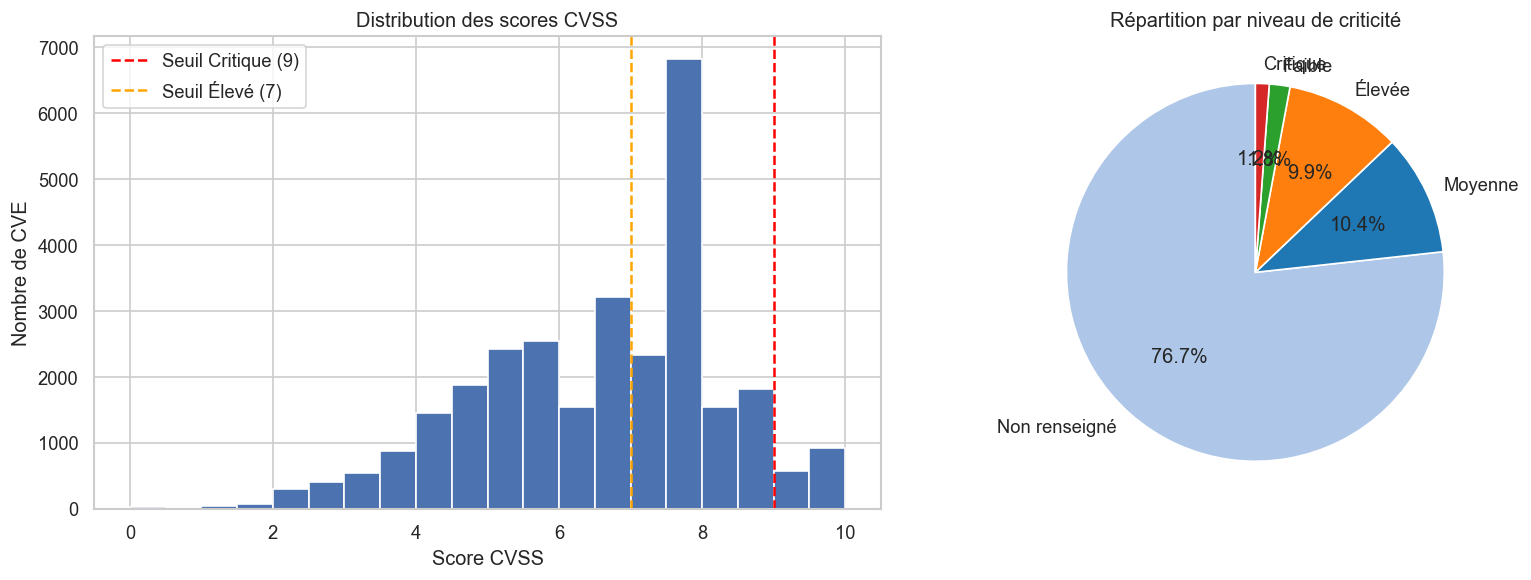

✅ Sauvegardé


In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
df_cvss = df[df["cvss_score"].notna()]
axes[0].hist(df_cvss["cvss_score"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(9, color="red", linestyle="--", label="Seuil Critique (9)")
axes[0].axvline(7, color="orange", linestyle="--", label="Seuil Élevé (7)")
axes[0].set_title("Distribution des scores CVSS")
axes[0].set_xlabel("Score CVSS")
axes[0].set_ylabel("Nombre de CVE")
axes[0].legend()

# Camembert criticité
colors = {"Critique": "#d62728", "Élevée": "#ff7f0e",
          "Moyenne": "#1f77b4", "Faible": "#2ca02c", "Non renseigné": "#aec7e8"}
counts = df["criticite"].value_counts()
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=[colors.get(c, "grey") for c in counts.index],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Répartition par niveau de criticité")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_cvss_distribution.png", bbox_inches="tight")
plt.show()
print("✅ Sauvegardé")

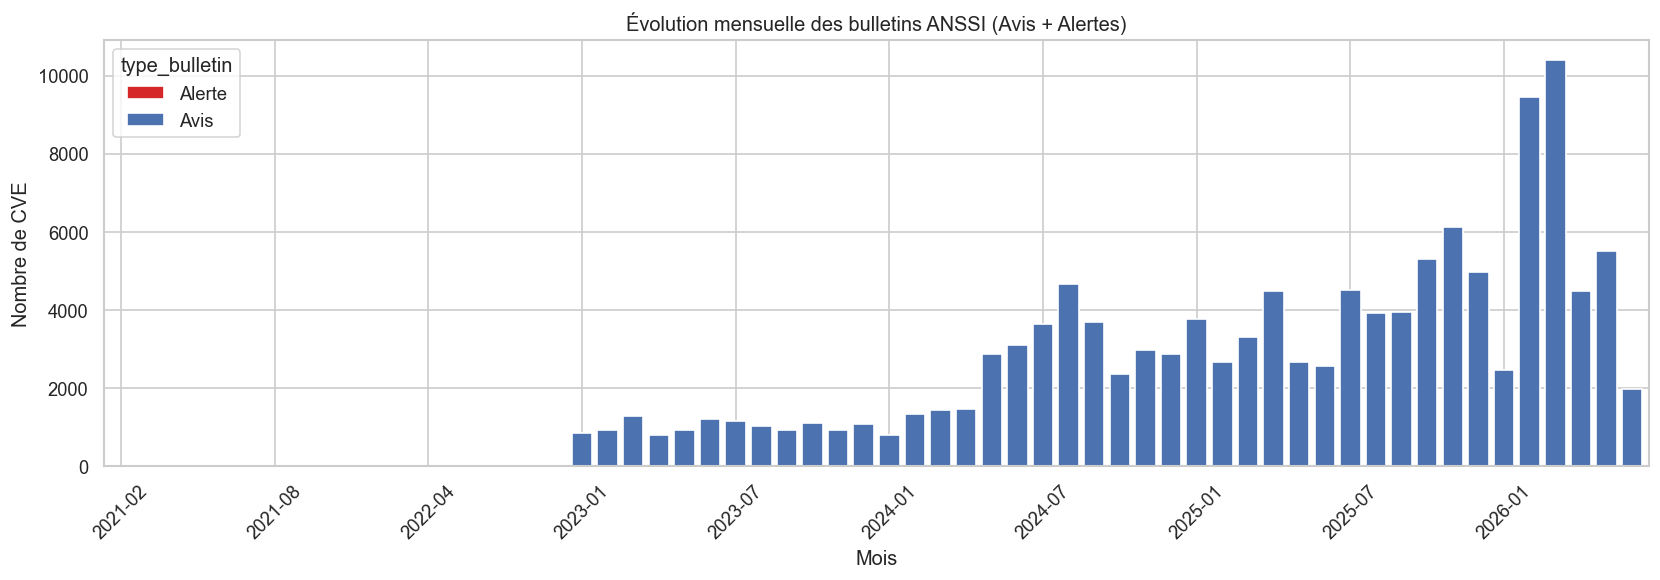

In [118]:
fig, ax = plt.subplots(figsize=(14, 5))

# CVE par mois
df_time = df.copy()
df_time["mois"] = df_time["date_publication"].dt.to_period("M")
evolution = df_time.groupby(["mois", "type_bulletin"]).size().unstack(fill_value=0)
evolution.index = evolution.index.astype(str)

evolution.plot(kind="bar", stacked=True, ax=ax,
               color={"Alerte": "#d62728", "Avis": "#4C72B0"}, width=0.8)
ax.set_title("Évolution mensuelle des bulletins ANSSI (Avis + Alertes)")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de CVE")
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_evolution_temporelle.png", bbox_inches="tight")
plt.show()

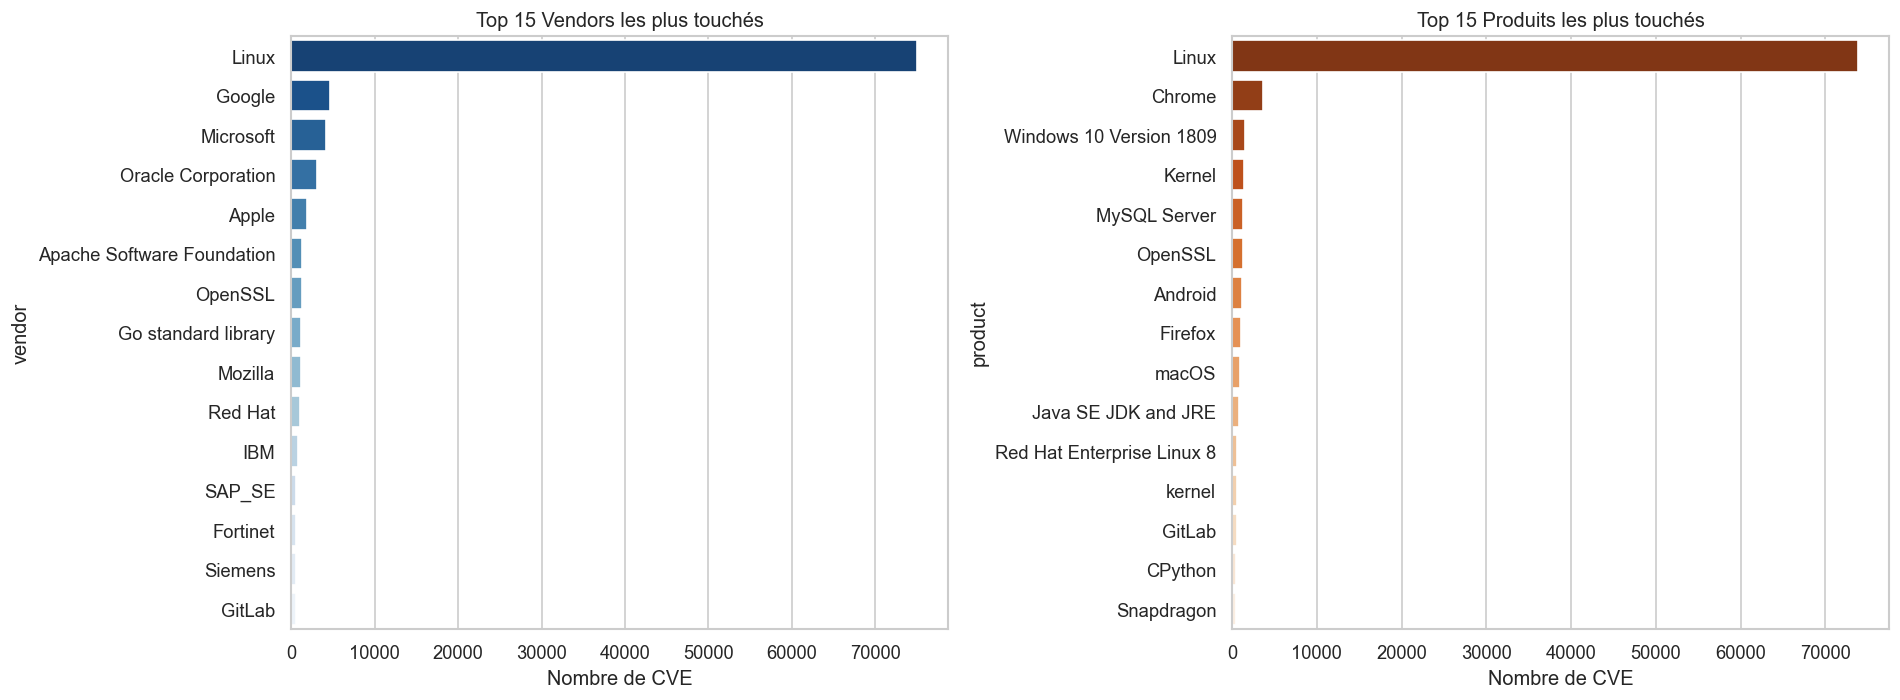

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 vendors
top_vendors = df[df["vendor"] != "N/A"]["vendor"].value_counts().head(15)
sns.barplot(x=top_vendors.values, y=top_vendors.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 15 Vendors les plus touchés")
axes[0].set_xlabel("Nombre de CVE")

# Top 15 produits
top_products = df[df["product"] != "N/A"]["product"].value_counts().head(15)
sns.barplot(x=top_products.values, y=top_products.index, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Top 15 Produits les plus touchés")
axes[1].set_xlabel("Nombre de CVE")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_top_vendors_products.png", bbox_inches="tight")
plt.show()

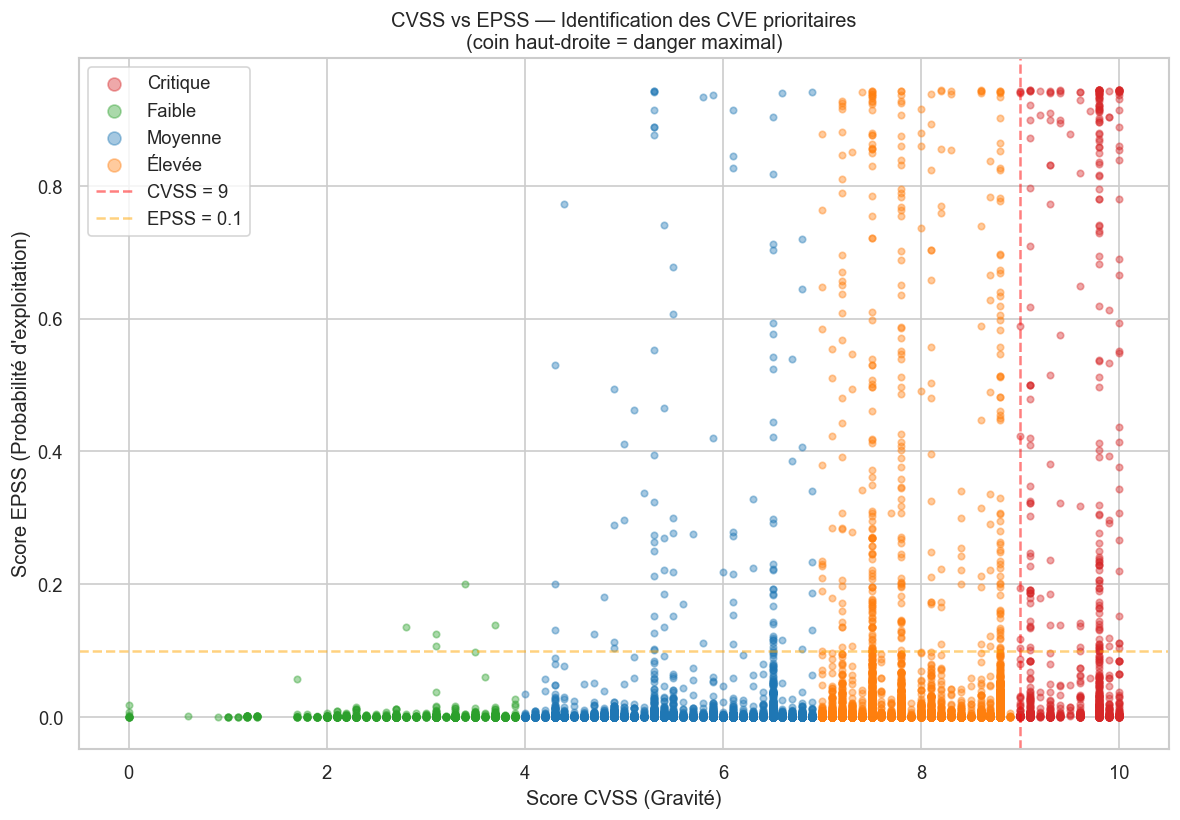

In [120]:
fig, ax = plt.subplots(figsize=(10, 7))

df_plot = df[df["cvss_score"].notna() & df["epss_score"].notna()].drop_duplicates("cve_id")
color_map = {"Critique": "#d62728", "Élevée": "#ff7f0e",
             "Moyenne": "#1f77b4", "Faible": "#2ca02c", "Non renseigné": "#aec7e8"}

for criticite, group in df_plot.groupby("criticite"):
    ax.scatter(group["cvss_score"], group["epss_score"],
               alpha=0.4, s=15, label=criticite,
               color=color_map.get(criticite, "grey"))

# Zones de danger
ax.axvline(9, color="red", linestyle="--", alpha=0.5, label="CVSS = 9")
ax.axhline(0.1, color="orange", linestyle="--", alpha=0.5, label="EPSS = 0.1")
ax.set_xlabel("Score CVSS (Gravité)")
ax.set_ylabel("Score EPSS (Probabilité d'exploitation)")
ax.set_title("CVSS vs EPSS — Identification des CVE prioritaires\n(coin haut-droite = danger maximal)")
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_cvss_vs_epss.png", bbox_inches="tight")
plt.show()

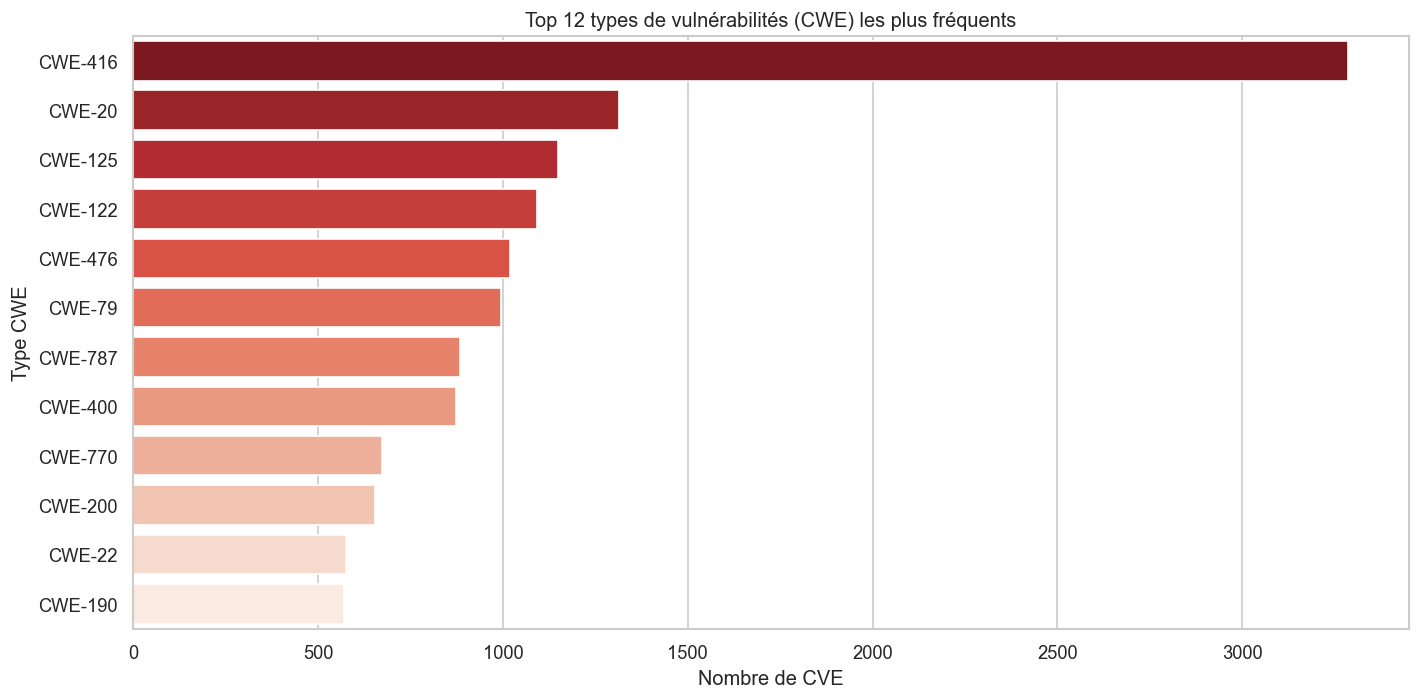

In [121]:
fig, ax = plt.subplots(figsize=(12, 6))

top_cwe = df[df["cwe_id"] != "N/A"]["cwe_id"].value_counts().head(12)
sns.barplot(x=top_cwe.values, y=top_cwe.index, palette="Reds_r", ax=ax)
ax.set_title("Top 12 types de vulnérabilités (CWE) les plus fréquents")
ax.set_xlabel("Nombre de CVE")
ax.set_ylabel("Type CWE")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_top_cwe.png", bbox_inches="tight")
plt.show()

## Visualisation avancée

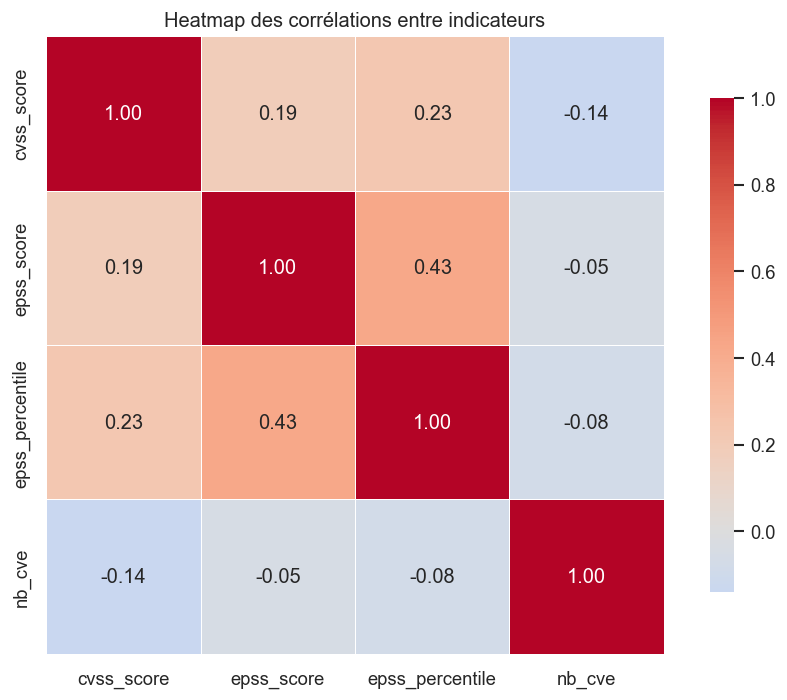

In [122]:
fig, ax = plt.subplots(figsize=(8, 6))

df_corr = df[["cvss_score", "epss_score", "epss_percentile", "nb_cve"]].dropna()
corr_matrix = df_corr.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Heatmap des corrélations entre indicateurs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_heatmap_correlation.png", bbox_inches="tight")
plt.show()

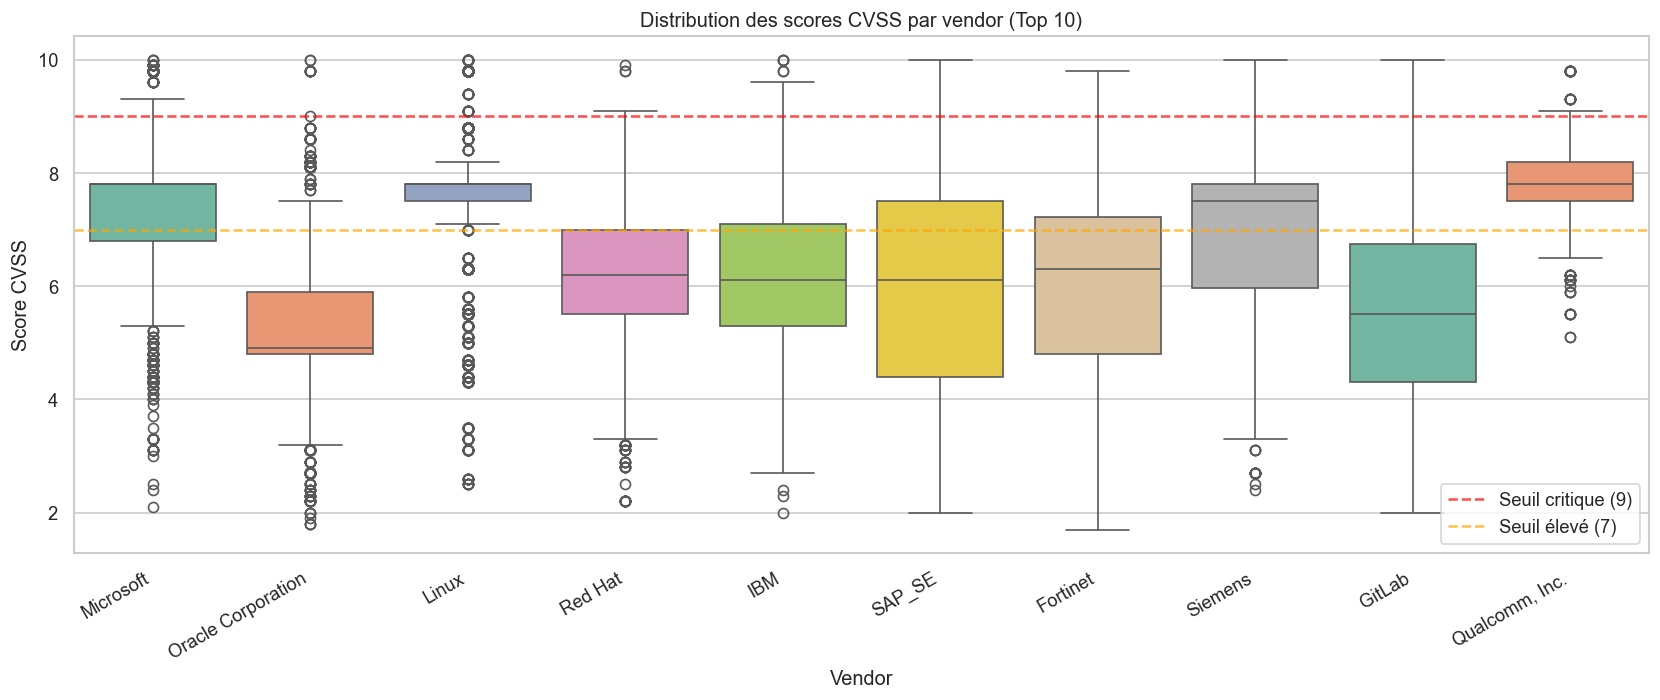

In [123]:
fig, ax = plt.subplots(figsize=(14, 6))

# Garder les 10 vendors avec le plus de CVE scorés
top10_vendors = (df[df["cvss_score"].notna() & (df["vendor"] != "N/A")]
                 ["vendor"].value_counts().head(10).index)

df_box = df[df["vendor"].isin(top10_vendors) & df["cvss_score"].notna()]

sns.boxplot(data=df_box, x="vendor", y="cvss_score",
            order=top10_vendors, palette="Set2", ax=ax)
ax.axhline(9, color="red", linestyle="--", alpha=0.7, label="Seuil critique (9)")
ax.axhline(7, color="orange", linestyle="--", alpha=0.7, label="Seuil élevé (7)")
ax.set_title("Distribution des scores CVSS par vendor (Top 10)")
ax.set_xlabel("Vendor")
ax.set_ylabel("Score CVSS")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_boxplot_cvss_vendor.png", bbox_inches="tight")
plt.show()

In [124]:
df_danger = (df[(df["cvss_score"] >= 9) & (df["epss_score"] >= 0.5)]
             .drop_duplicates("cve_id")
             .sort_values("risque_combine", ascending=False)
             [["cve_id", "cvss_score", "epss_score", "risque_combine",
               "vendor", "product", "cwe_id", "criticite"]]
             .head(20))

print(f"🚨 CVE à risque maximal (CVSS≥9 ET EPSS≥0.5) : {len(df_danger)}")
df_danger.style.background_gradient(subset=["cvss_score", "epss_score", "risque_combine"],
                                     cmap="Reds")

🚨 CVE à risque maximal (CVSS≥9 ET EPSS≥0.5) : 20


,cve_id,cvss_score,epss_score,risque_combine,vendor,product,cwe_id,criticite
103,CVE-2023-35078,10.000000,0.944820,9.448200,Ivanti,Endpoint Manager Mobile,nan,Critique
9259,CVE-2023-40044,10.000000,0.944490,9.444900,Progress Software Corporation,WS_FTP Server,CWE-502,Critique
10519,CVE-2023-46604,10.000000,0.944360,9.443600,Apache Software Foundation,Apache ActiveMQ,CWE-502,Critique
105,CVE-2023-35082,10.000000,0.944230,9.442300,Ivanti,EPMM,nan,Critique
10348,CVE-2023-22518,10.000000,0.943750,9.437500,Atlassian,Confluence Data Center,nan,Critique
12846,CVE-2023-22527,10.000000,0.943630,9.436300,Atlassian,Confluence Data Center,nan,Critique
11112,CVE-2023-49103,10.000000,0.943290,9.432900,nan,nan,nan,Critique
9288,CVE-2023-22515,10.000000,0.943260,9.432600,Atlassian,Confluence Data Center,nan,Critique
127,CVE-2024-3400,10.000000,0.942970,9.429700,Palo Alto Networks,PAN-OS,CWE-77,Critique
31963,CVE-2024-45519,10.000000,0.941400,9.414000,nan,nan,nan,Critique


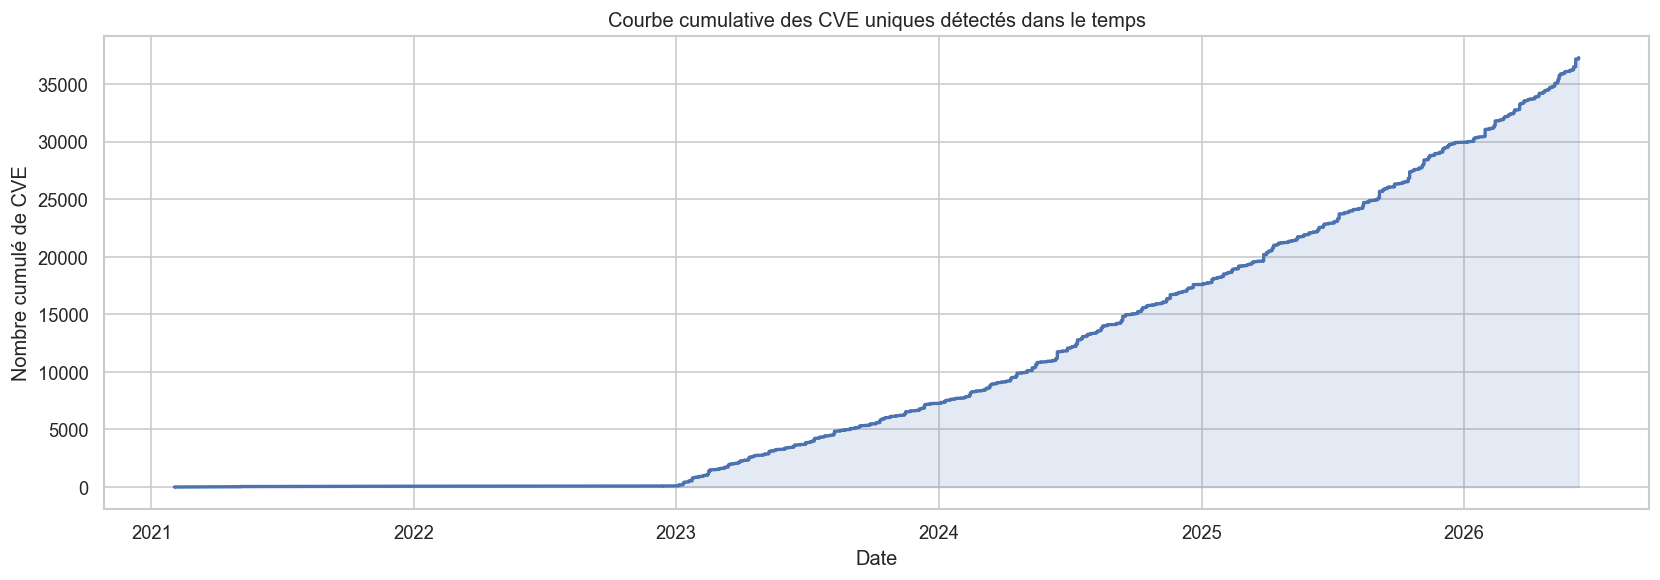

In [125]:
fig, ax = plt.subplots(figsize=(14, 5))

df_cum = (df.drop_duplicates("cve_id")
            .dropna(subset=["date_publication"])
            .sort_values("date_publication"))

df_cum["cumul"] = range(1, len(df_cum) + 1)

ax.plot(df_cum["date_publication"], df_cum["cumul"],
        color="#4C72B0", linewidth=2)
ax.fill_between(df_cum["date_publication"], df_cum["cumul"],
                alpha=0.15, color="#4C72B0")
ax.set_title("Courbe cumulative des CVE uniques détectés dans le temps")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre cumulé de CVE")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_courbe_cumulative.png", bbox_inches="tight")
plt.show()

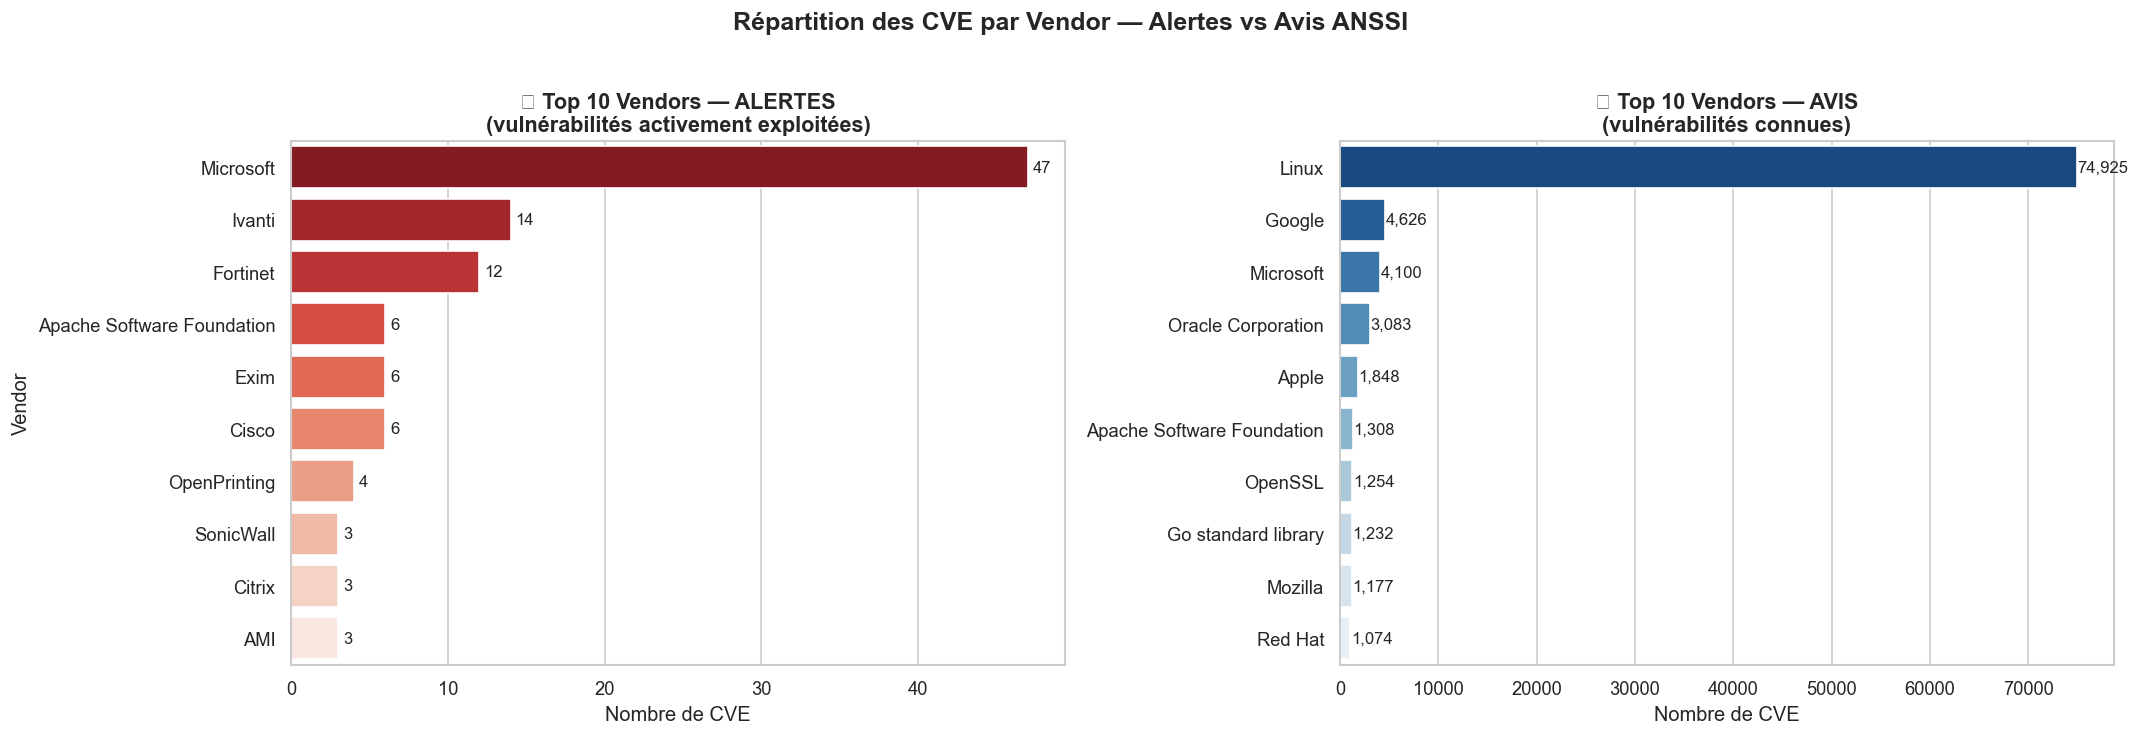

💡 Insights :
  Alertes : Microsoft domine avec 47 CVE activement exploités
  Avis    : Linux domine avec 74,925 CVE référencés
  → Linux a beaucoup de CVE référencés mais peu d'alertes critiques
  → Microsoft concentre les vulnérabilités les plus dangereuses


In [126]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Graphique 1 : Top 10 vendors par ALERTES ---
top_alertes = (df[df["type_bulletin"] == "Alerte"]
               [df["vendor"] != "N/A"]["vendor"]
               .value_counts().head(10))

sns.barplot(x=top_alertes.values, y=top_alertes.index,
            palette="Reds_r", ax=axes[0])
axes[0].set_title("🚨 Top 10 Vendors — ALERTES\n(vulnérabilités activement exploitées)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Nombre de CVE")
axes[0].set_ylabel("Vendor")
for i, v in enumerate(top_alertes.values):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=10)

# --- Graphique 2 : Top 10 vendors par AVIS ---
top_avis = (df[df["type_bulletin"] == "Avis"]
            [df["vendor"] != "N/A"]["vendor"]
            .value_counts().head(10))

sns.barplot(x=top_avis.values, y=top_avis.index,
            palette="Blues_r", ax=axes[1])
axes[1].set_title("📋 Top 10 Vendors — AVIS\n(vulnérabilités connues)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Nombre de CVE")
axes[1].set_ylabel("")
for i, v in enumerate(top_avis.values):
    axes[1].text(v + 50, i, f"{v:,}", va="center", fontsize=10)

plt.suptitle("Répartition des CVE par Vendor — Alertes vs Avis ANSSI",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_vendors_alertes_vs_avis.png", bbox_inches="tight")
plt.show()

# --- Insight textuel ---
print("💡 Insights :")
print(f"  Alertes : Microsoft domine avec {top_alertes['Microsoft']} CVE activement exploités")
print(f"  Avis    : Linux domine avec {top_avis['Linux']:,} CVE référencés")
print(f"  → Linux a beaucoup de CVE référencés mais peu d'alertes critiques")
print(f"  → Microsoft concentre les vulnérabilités les plus dangereuses")

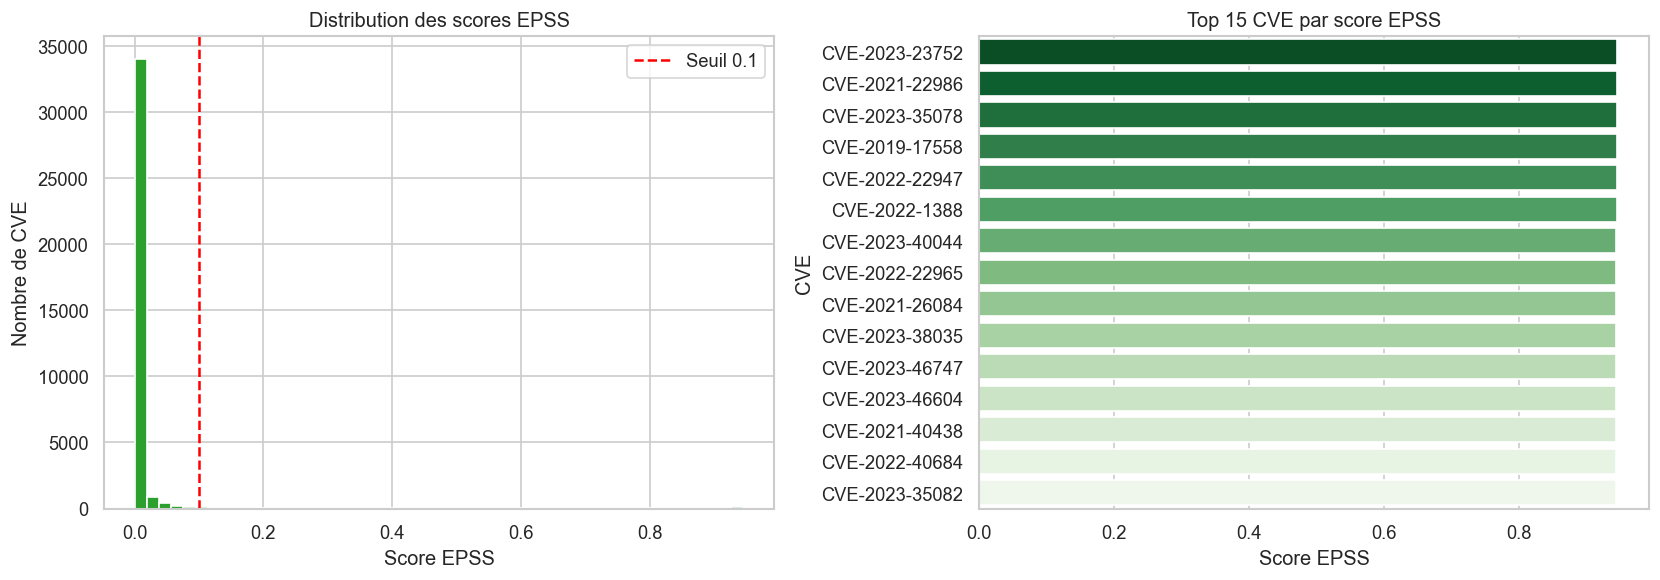

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_epss = df[df["epss_score"].notna()].drop_duplicates("cve_id")

# Histogramme EPSS
axes[0].hist(df_epss["epss_score"], bins=50,
             color="#2ca02c", edgecolor="white")
axes[0].axvline(0.1, color="red", linestyle="--", label="Seuil 0.1")
axes[0].set_title("Distribution des scores EPSS")
axes[0].set_xlabel("Score EPSS")
axes[0].set_ylabel("Nombre de CVE")
axes[0].legend()

# Top 15 CVE par score EPSS
top_epss = df_epss.nlargest(15, "epss_score")[["cve_id", "epss_score", "vendor"]]
sns.barplot(data=top_epss, x="epss_score", y="cve_id",
            palette="Greens_r", ax=axes[1])
axes[1].set_title("Top 15 CVE par score EPSS")
axes[1].set_xlabel("Score EPSS")
axes[1].set_ylabel("CVE")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_epss_distribution.png", bbox_inches="tight")
plt.show()

# Etape 6 : Machine Learning

In [128]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, silhouette_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Base : uniquement les CVE avec CVSS et EPSS renseignés
df_ml = (df[df["cvss_score"].notna() & df["epss_score"].notna()]
         .drop_duplicates("cve_id")
         .copy())

# Encoder le CWE (garder les 20 plus fréquents, reste = "Autre")
top_cwe = df_ml["cwe_id"].value_counts().head(20).index
df_ml["cwe_encoded"] = df_ml["cwe_id"].apply(lambda x: x if x in top_cwe else "Autre")
le = LabelEncoder()
df_ml["cwe_encoded"] = le.fit_transform(df_ml["cwe_encoded"])

# Encoder le type de bulletin
df_ml["type_encoded"] = (df_ml["type_bulletin"] == "Alerte").astype(int)

# Features utilisées
FEATURES = ["cvss_score", "epss_score", "epss_percentile",
            "cwe_encoded", "type_encoded", "nb_cve"]

df_ml = df_ml.dropna(subset=FEATURES).reset_index(drop=True)

print(f"✅ Dataset ML : {len(df_ml):,} CVE uniques")
print(f"   Features   : {FEATURES}")
print(f"\nRépartition criticité :")
print(df_ml["criticite"].value_counts())

✅ Dataset ML : 17,063 CVE uniques
   Features   : ['cvss_score', 'epss_score', 'epss_percentile', 'cwe_encoded', 'type_encoded', 'nb_cve']

Répartition criticité :
criticite
Élevée      7569
Moyenne     7424
Faible      1103
Critique     967
Name: count, dtype: int64


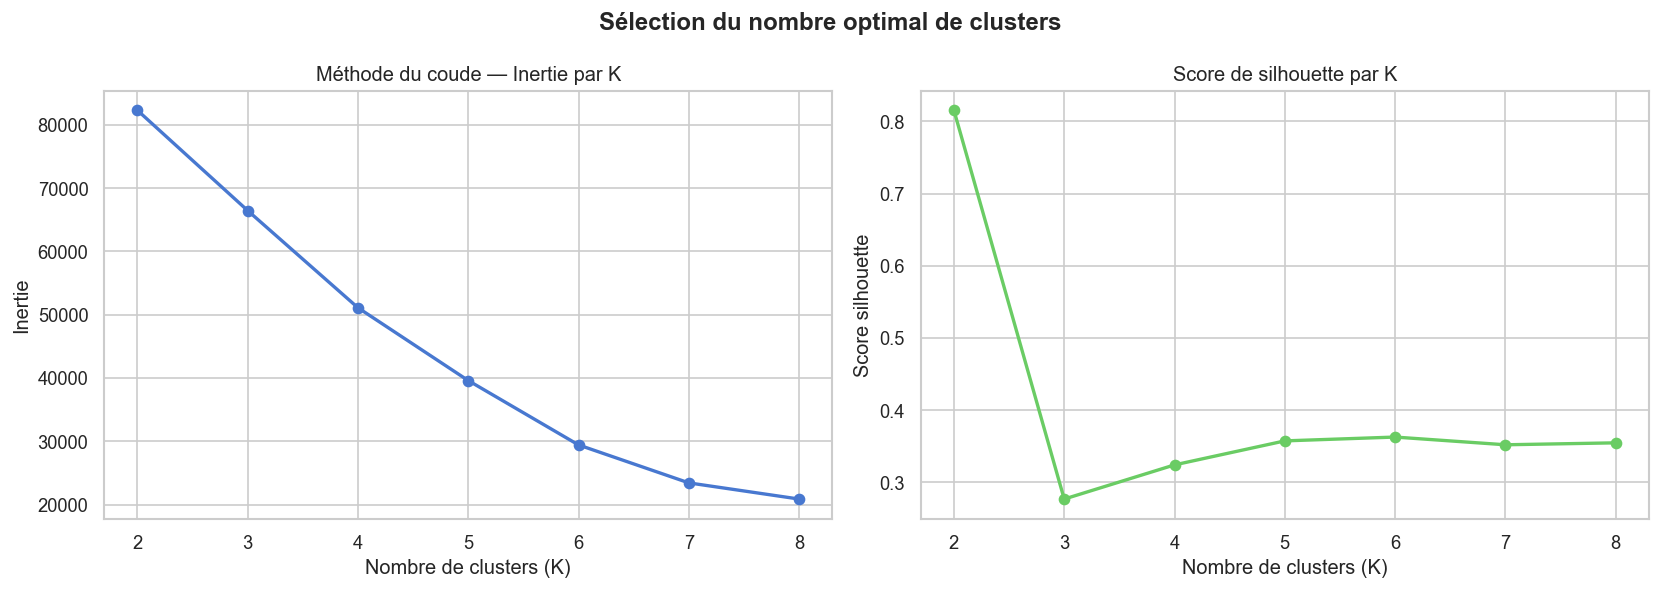

✅ Meilleur K selon silhouette : 2


In [129]:
# --- Préparation ---
X = df_ml[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Trouver le bon nombre de clusters (méthode du coude) ---
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "bo-", linewidth=2)
axes[0].set_title("Méthode du coude — Inertie par K")
axes[0].set_xlabel("Nombre de clusters (K)")
axes[0].set_ylabel("Inertie")

axes[1].plot(K_range, silhouettes, "go-", linewidth=2)
axes[1].set_title("Score de silhouette par K")
axes[1].set_xlabel("Nombre de clusters (K)")
axes[1].set_ylabel("Score silhouette")

plt.suptitle("Sélection du nombre optimal de clusters", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_ml_kmeans_selection.png", bbox_inches="tight")
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"✅ Meilleur K selon silhouette : {best_k}")

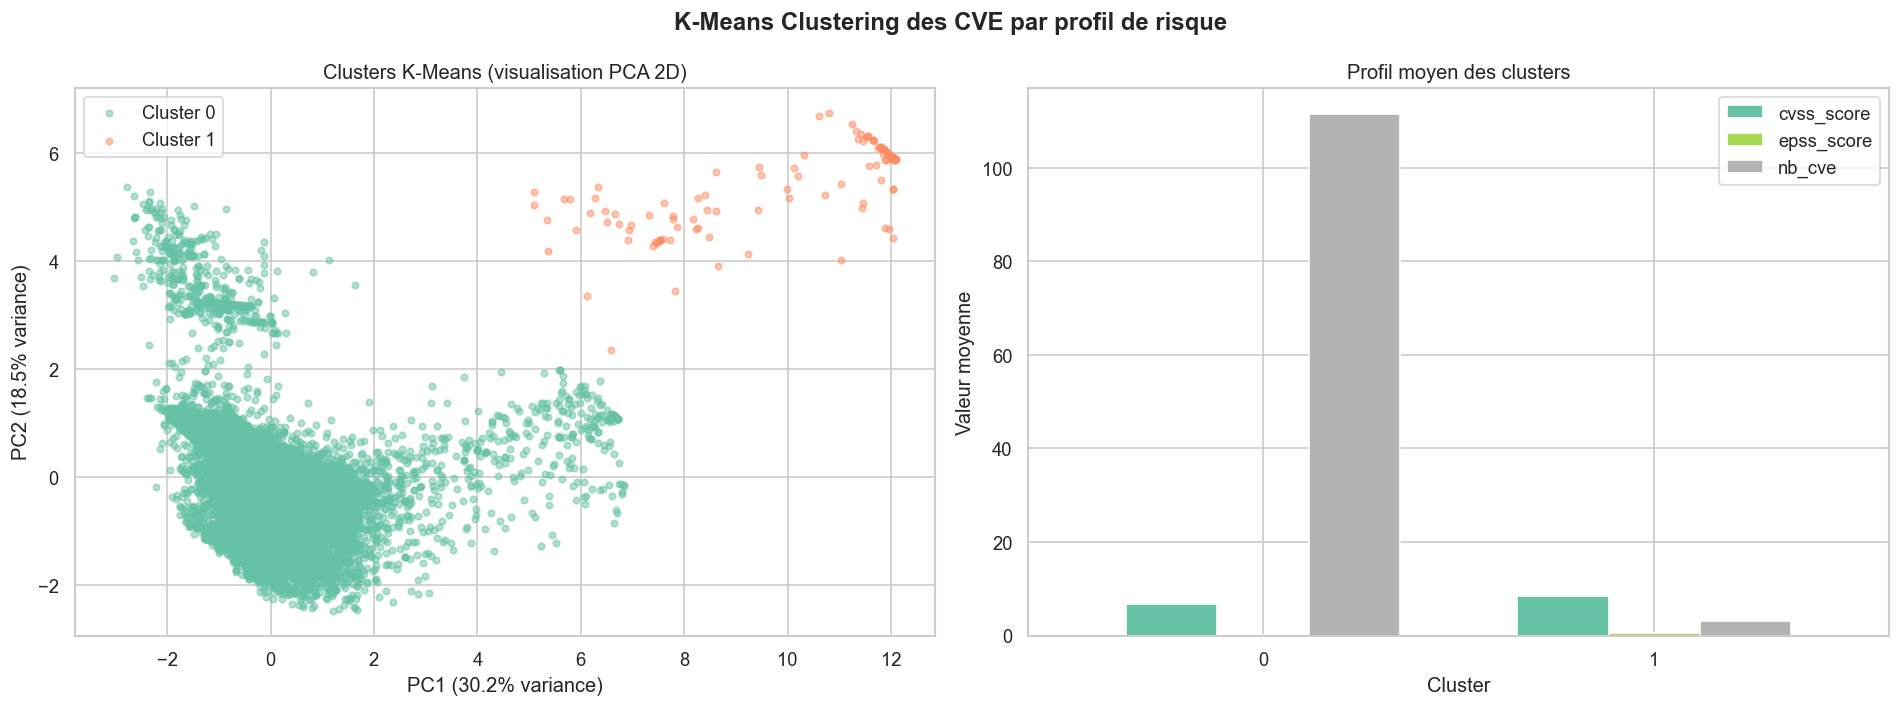


=== Profil des clusters ===

Cluster 0 (16,957 CVE) :
  CVSS moyen    : 6.65
  EPSS moyen    : 0.0207
  % Critiques   : 5.4%
  Top vendor    : Microsoft

Cluster 1 (106 CVE) :
  CVSS moyen    : 8.46
  EPSS moyen    : 0.5644
  % Critiques   : 49.1%
  Top vendor    : Microsoft


In [130]:
# --- Appliquer K-Means avec le meilleur K ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_ml["cluster"] = kmeans.fit_predict(X_scaled)

# --- PCA pour visualisation 2D ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_ml["pca1"] = X_pca[:, 0]
df_ml["pca2"] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter par cluster
palette = sns.color_palette("Set2", best_k)
for c in range(best_k):
    mask = df_ml["cluster"] == c
    axes[0].scatter(df_ml[mask]["pca1"], df_ml[mask]["pca2"],
                    s=15, alpha=0.5, color=palette[c], label=f"Cluster {c}")
axes[0].set_title("Clusters K-Means (visualisation PCA 2D)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].legend()

# Profil moyen par cluster
profil = df_ml.groupby("cluster")[["cvss_score", "epss_score", "nb_cve"]].mean()
profil.plot(kind="bar", ax=axes[1], colormap="Set2", width=0.7)
axes[1].set_title("Profil moyen des clusters")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Valeur moyenne")
axes[1].legend(loc="upper right")
plt.xticks(rotation=0)

plt.suptitle("K-Means Clustering des CVE par profil de risque", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_ml_kmeans_clusters.png", bbox_inches="tight")
plt.show()

# Décrire chaque cluster
print("\n=== Profil des clusters ===")
for c in range(best_k):
    subset = df_ml[df_ml["cluster"] == c]
    print(f"\nCluster {c} ({len(subset):,} CVE) :")
    print(f"  CVSS moyen    : {subset['cvss_score'].mean():.2f}")
    print(f"  EPSS moyen    : {subset['epss_score'].mean():.4f}")
    print(f"  % Critiques   : {(subset['cvss_score'] >= 9).mean()*100:.1f}%")
    print(f"  Top vendor    : {subset['vendor'].value_counts().index[0]}")

In [131]:
# --- Cible : CVE critique (CVSS >= 9) ---
df_ml["is_critique"] = (df_ml["cvss_score"] >= 9).astype(int)

print("Répartition de la cible :")
print(df_ml["is_critique"].value_counts())
print(f"  → {df_ml['is_critique'].mean()*100:.1f}% de CVE critiques")

X_sup = df_ml[FEATURES].values
y_sup = df_ml["is_critique"].values

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_sup, y_sup, test_size=0.2, random_state=42, stratify=y_sup)

# Entraînement
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred,
      target_names=["Non critique", "Critique"]))

Répartition de la cible :
is_critique
0    16096
1      967
Name: count, dtype: int64
  → 5.7% de CVE critiques

=== Rapport de classification ===
              precision    recall  f1-score   support

Non critique       1.00      1.00      1.00      3220
    Critique       1.00      1.00      1.00       193

    accuracy                           1.00      3413
   macro avg       1.00      1.00      1.00      3413
weighted avg       1.00      1.00      1.00      3413



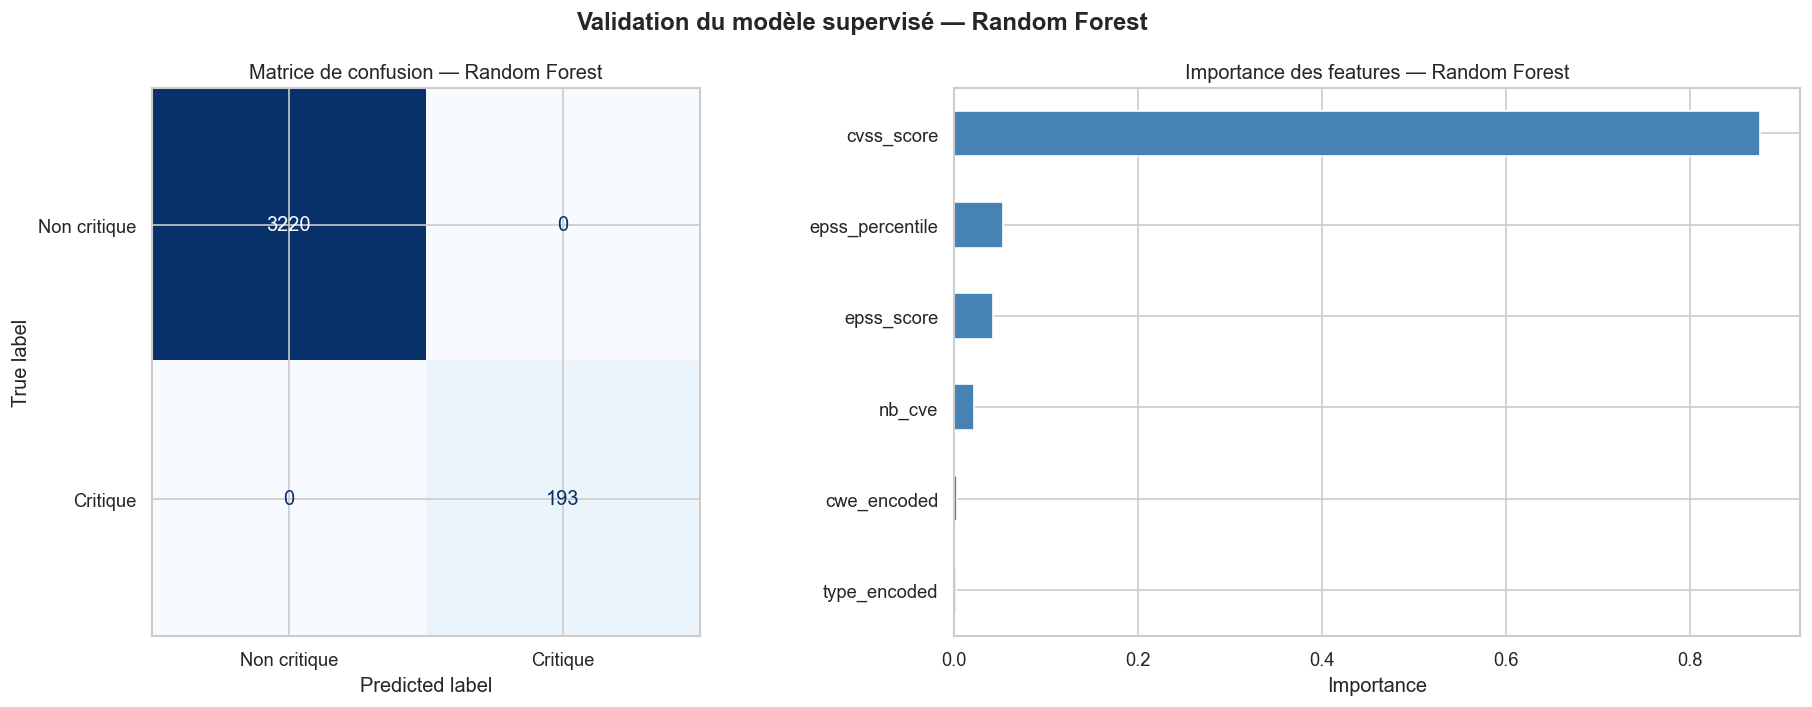


=== Cross-validation (5-fold) ===
  F1 par fold : ['1.000', '1.000', '1.000', '1.000', '1.000']
  F1 moyen    : 1.000 (+/- 0.000)


In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non critique", "Critique"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matrice de confusion — Random Forest")

# --- Feature importance ---
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Importance des features — Random Forest")
axes[1].set_xlabel("Importance")

plt.suptitle("Validation du modèle supervisé — Random Forest", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_ml_random_forest.png", bbox_inches="tight")
plt.show()

# --- Cross-validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X_sup, y_sup, cv=cv, scoring="f1")
print(f"\n=== Cross-validation (5-fold) ===")
print(f"  F1 par fold : {[f'{s:.3f}' for s in scores]}")
print(f"  F1 moyen    : {scores.mean():.3f} (+/- {scores.std():.3f})")

## ⚠️ Problème détecté : Data Leakage

Le modèle V1 (avec `cvss_score`) obtient un F1 parfait de 1.000 car la **cible
est directement dérivée du CVSS** (critique = CVSS ≥ 9). Le modèle "triche"
sans réellement apprendre.

→ Nous corrigeons en retirant `cvss_score` des features (V2).

=== Rapport de classification (sans data leakage) ===
              precision    recall  f1-score   support

Non critique       0.96      0.96      0.96      3220
    Critique       0.34      0.37      0.35       193

    accuracy                           0.92      3413
   macro avg       0.65      0.66      0.66      3413
weighted avg       0.93      0.92      0.93      3413



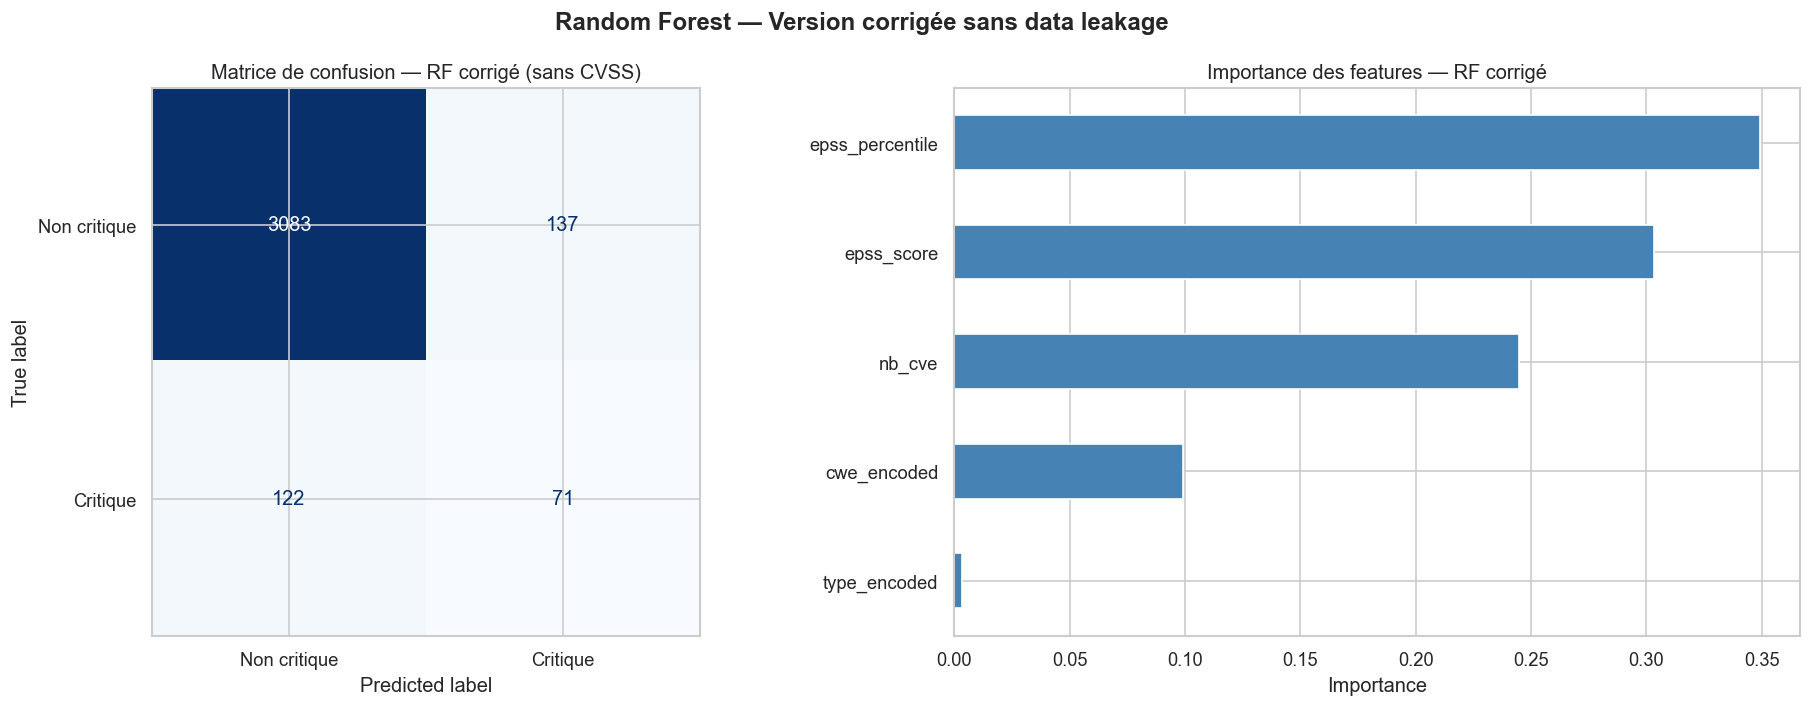


=== Cross-validation corrigée (5-fold) ===
  F1 par fold : ['0.341', '0.359', '0.342', '0.358', '0.326']
  F1 moyen    : 0.345 (+/- 0.012)

💡 Interprétation :
  Ce modèle prédit la criticité SANS connaître le CVSS
  Il se base uniquement sur EPSS, CWE et le contexte du bulletin


In [133]:
# ============================================================
# Cellule 6 — Random Forest corrigé (sans data leakage)
# ============================================================

FEATURES_CORRIGES = ["epss_score", "epss_percentile", "cwe_encoded",
                     "type_encoded", "nb_cve"]

X_sup2 = df_ml[FEATURES_CORRIGES].values
y_sup2 = df_ml["is_critique"].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_sup2, y_sup2, test_size=0.2, random_state=42, stratify=y_sup2)

rf2 = RandomForestClassifier(n_estimators=200, random_state=42,
                              class_weight="balanced", n_jobs=-1)
rf2.fit(X_train2, y_train2)
y_pred2 = rf2.predict(X_test2)

print("=== Rapport de classification (sans data leakage) ===")
print(classification_report(y_test2, y_pred2,
      target_names=["Non critique", "Critique"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice de confusion
cm2 = confusion_matrix(y_test2, y_pred2)
ConfusionMatrixDisplay(cm2, display_labels=["Non critique", "Critique"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matrice de confusion — RF corrigé (sans CVSS)")

# Feature importance
importances2 = pd.Series(rf2.feature_importances_,
                          index=FEATURES_CORRIGES).sort_values()
importances2.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Importance des features — RF corrigé")
axes[1].set_xlabel("Importance")

plt.suptitle("Random Forest — Version corrigée sans data leakage",
             fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/viz_ml_rf_corrige.png", bbox_inches="tight")
plt.show()

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores2 = cross_val_score(rf2, X_sup2, y_sup2, cv=cv, scoring="f1")
print(f"\n=== Cross-validation corrigée (5-fold) ===")
print(f"  F1 par fold : {[f'{s:.3f}' for s in scores2]}")
print(f"  F1 moyen    : {scores2.mean():.3f} (+/- {scores2.std():.3f})")
print(f"\n💡 Interprétation :")
print(f"  Ce modèle prédit la criticité SANS connaître le CVSS")
print(f"  Il se base uniquement sur EPSS, CWE et le contexte du bulletin")

## 📊 Analyse comparative des deux modèles Random Forest

| | V1 (avec CVSS) | V2 (sans CVSS) |
|---|---|---|
| F1 moyen | 1.000 | 0.331 |
| Data leakage | ✅ Oui | ❌ Non |
| Utilisable en production | ❌ Non | ✅ Oui |

### Interprétation V2 :
- **F1 = 0.331** : le modèle a du mal à détecter les critiques car seulement
  5.7% des CVE le sont → dataset très déséquilibré
- **152 faux négatifs** : des CVE critiques non détectés → dangereux en prod
- **32 faux positifs** : des CVE non critiques signalés comme critiques → acceptable

### Features les plus importantes (V2) :
1. `epss_percentile` (0.35) — rang de dangerosité relatif
2. `epss_score` (0.30) — probabilité d'exploitation absolue
3. `nb_cve` (0.25) — les bulletins avec beaucoup de CVE tendent à être plus critiques
4. `cwe_encoded` (0.10) — le type de vulnérabilité a un impact modéré

### Conclusion :
Sans le score CVSS, l'**EPSS est le meilleur prédicteur de criticité**,
ce qui est cohérent : une vulnérabilité activement exploitée dans la nature
est par définition critique, indépendamment de son score théorique.

# Etape 7 : Génération d'alertes et notifications d'email

In [134]:
# ============================================================
# ÉTAPE 7 — GÉNÉRATION D'ALERTES ET NOTIFICATIONS EMAIL
# ============================================================

# Seuils d'alerte configurables
SEUIL_CVSS = 9.0        # Score CVSS minimum
SEUIL_EPSS = 0.5        # Probabilité d'exploitation minimum
PRODUITS_SURVEILLES = [ # Produits à surveiller (personnalisable)
    "Windows", "Linux", "Apache", "Cisco", "Fortinet",
    "VMware", "Microsoft Exchange", "Ivanti", "OpenSSL"
]

def detecter_alertes(df, seuil_cvss=SEUIL_CVSS, seuil_epss=SEUIL_EPSS,
                     produits=PRODUITS_SURVEILLES):
    """Détecte les CVE nécessitant une alerte immédiate"""

    # Critère 1 : CVSS critique ET EPSS élevé
    masque_risque = (
        (df["cvss_score"] >= seuil_cvss) &
        (df["epss_score"] >= seuil_epss)
    )

    # Critère 2 : produit surveillé
    masque_produit = df["product"].apply(
        lambda p: any(prod.lower() in str(p).lower() for prod in produits)
    )

    df_alertes = (df[masque_risque | (masque_risque & masque_produit)]
                  .drop_duplicates("cve_id")
                  .sort_values("risque_combine", ascending=False)
                  .copy())

    return df_alertes

df_alertes = detecter_alertes(df)

print(f"🚨 {len(df_alertes)} CVE nécessitent une alerte immédiate")
print(f"\nTop 10 CVE les plus dangereux :")
print(df_alertes[["cve_id", "cvss_score", "epss_score", "vendor",
                   "product", "type_bulletin"]].head(10).to_string(index=False))

🚨 129 CVE nécessitent une alerte immédiate

Top 10 CVE les plus dangereux :
        cve_id  cvss_score  epss_score                        vendor                 product type_bulletin
CVE-2023-35078        10.0     0.94482                        Ivanti Endpoint Manager Mobile        Alerte
CVE-2023-40044        10.0     0.94449 Progress Software Corporation           WS_FTP Server          Avis
CVE-2023-46604        10.0     0.94436    Apache Software Foundation         Apache ActiveMQ          Avis
CVE-2023-35082        10.0     0.94423                        Ivanti                    EPMM        Alerte
CVE-2023-22518        10.0     0.94375                     Atlassian  Confluence Data Center          Avis
CVE-2023-22527        10.0     0.94363                     Atlassian  Confluence Data Center          Avis
CVE-2023-49103        10.0     0.94329                           NaN                     NaN          Avis
CVE-2023-22515        10.0     0.94326                     Atlassian

In [135]:
from datetime import datetime

def generer_email_alerte(df_alertes, destinataire="securite@entreprise.com"):
    """Génère le sujet et le corps de l'email d'alerte"""

    nb_alertes = len(df_alertes)
    date_today = datetime.now().strftime("%d/%m/%Y")
    cvss_max = df_alertes["cvss_score"].max()
    epss_max = df_alertes["epss_score"].max()
    top_vendor = df_alertes["vendor"].value_counts().index[0]

    # --- SUJET ---
    sujet = (f"🚨 [ANSSI] {nb_alertes} vulnérabilités critiques détectées "
             f"— Action requise ({date_today})")

    # --- CORPS ---
    corps = f"""
╔══════════════════════════════════════════════════════════════╗
║           ALERTE SÉCURITÉ — BULLETIN ANSSI CERT-FR          ║
║                     {date_today}                            ║
╚══════════════════════════════════════════════════════════════╝

Bonjour,

Notre système de veille automatisé a détecté {nb_alertes} vulnérabilité(s)
critique(s) nécessitant une intervention IMMÉDIATE.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 RÉSUMÉ EXÉCUTIF
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Nombre de CVE critiques     : {nb_alertes}
  • Score CVSS maximum          : {cvss_max:.1f} / 10
  • Probabilité exploitation max: {epss_max:.1%}
  • Éditeur le plus impacté     : {top_vendor}
  • Seuils d'alerte appliqués   : CVSS ≥ {SEUIL_CVSS} ET EPSS ≥ {SEUIL_EPSS}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔴 TOP 5 VULNÉRABILITÉS PRIORITAIRES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
    for i, (_, row) in enumerate(df_alertes.head(5).iterrows(), 1):
        corps += f"""
  [{i}] {row['cve_id']}
       Produit     : {row['vendor']} — {row['product']}
       CVSS        : {row['cvss_score']:.1f}/10 ({row['cvss_severity']})
       EPSS        : {row['epss_score']:.1%} de probabilité d'exploitation
       Type        : {row['type_bulletin']} ANSSI
       CWE         : {row['cwe_id']}
       Lien ANSSI  : {row['lien']}
       Description : {str(row['description'])[:120]}...
"""

    corps += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 LISTE COMPLÈTE DES {nb_alertes} CVE CRITIQUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

{'CVE ID':<20} {'CVSS':>6} {'EPSS':>8} {'VENDOR':<20} {'PRODUIT'}
{'-'*80}
"""
    for _, row in df_alertes.iterrows():
        corps += (f"{row['cve_id']:<20} {row['cvss_score']:>6.1f} "
                  f"{row['epss_score']:>8.1%} {str(row['vendor']):<20} "
                  f"{str(row['product'])[:30]}\n")

    corps += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ ACTIONS RECOMMANDÉES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. Appliquer immédiatement les correctifs disponibles
  2. Isoler les systèmes affectés si aucun patch n'est disponible
  3. Surveiller les logs pour détecter toute exploitation
  4. Consulter les bulletins ANSSI pour les recommandations détaillées
     → https://www.cert.ssi.gouv.fr/

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Ce message est généré automatiquement par le système de veille ANSSI.
Destinataire : {destinataire}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
    return sujet, corps

# Générer l'email
sujet, corps = generer_email_alerte(df_alertes)

print("=" * 60)
print("SUJET :", sujet)
print("=" * 60)
print(corps)

SUJET : 🚨 [ANSSI] 129 vulnérabilités critiques détectées — Action requise (14/06/2026)

╔══════════════════════════════════════════════════════════════╗
║           ALERTE SÉCURITÉ — BULLETIN ANSSI CERT-FR          ║
║                     14/06/2026                            ║
╚══════════════════════════════════════════════════════════════╝

Bonjour,

Notre système de veille automatisé a détecté 129 vulnérabilité(s)
critique(s) nécessitant une intervention IMMÉDIATE.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 RÉSUMÉ EXÉCUTIF
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Nombre de CVE critiques     : 129
  • Score CVSS maximum          : 10.0 / 10
  • Probabilité exploitation max: 94.5%
  • Éditeur le plus impacté     : Microsoft
  • Seuils d'alerte appliqués   : CVSS ≥ 9.0 ET EPSS ≥ 0.5

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔴 TOP 5 VULNÉRABILITÉS PRIORITAIRES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 

In [136]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def envoyer_email(destinataire, sujet, corps,
                  expediteur="votre_email@gmail.com",
                  mot_de_passe="votre_mot_de_passe_application"):
    """
    Envoie l'email d'alerte via Gmail SMTP.
    ⚠️  Utiliser un 'mot de passe d'application' Gmail
        (Compte Google → Sécurité → Validation en 2 étapes → Mots de passe d'application)
    """
    try:
        msg = MIMEMultipart("alternative")
        msg["From"]    = expediteur
        msg["To"]      = destinataire
        msg["Subject"] = sujet

        # Corps texte brut
        msg.attach(MIMEText(corps, "plain", "utf-8"))

        with smtplib.SMTP("smtp.gmail.com", 587) as server:
            server.starttls()
            server.login(expediteur, mot_de_passe)
            server.sendmail(expediteur, destinataire, msg.as_string())

        print(f"✅ Email envoyé à {destinataire}")

    except Exception as e:
        print(f"❌ Erreur envoi : {e}")

# --- Décommenter pour envoyer réellement ---
# envoyer_email(
#     destinataire  = "destinataire@email.com",
#     sujet         = sujet,
#     corps         = corps,
#     expediteur    = "votre_email@gmail.com",
#     mot_de_passe  = "xxxx xxxx xxxx xxxx"  # mot de passe application Gmail
# )

print("📧 Fonction d'envoi prête — décommenter pour envoyer")
print(f"   Sujet   : {sujet[:60]}...")
print(f"   Lignes  : {len(corps.splitlines())} lignes")
print(f"   CVE     : {len(df_alertes)} vulnérabilités dans l'email")

📧 Fonction d'envoi prête — décommenter pour envoyer
   Sujet   : 🚨 [ANSSI] 129 vulnérabilités critiques détectées — Action re...
   Lignes  : 220 lignes
   CVE     : 129 vulnérabilités dans l'email


In [137]:
# Sauvegarder la liste des CVE critiques en CSV
df_alertes.to_csv(OUTPUT_DIR + "/alertes_critiques.csv", index=False)

# Sauvegarder l'email en fichier texte
with open(OUTPUT_DIR + "/email_alerte.txt", "w", encoding="utf-8") as f:
    f.write(f"SUJET : {sujet}\n")
    f.write("=" * 60 + "\n")
    f.write(corps)

print(f"✅ Rapport sauvegardé :")
print(f"   → alertes_critiques.csv ({len(df_alertes)} CVE)")
print(f"   → email_alerte.txt")

✅ Rapport sauvegardé :
   → alertes_critiques.csv (129 CVE)
   → email_alerte.txt
